

---

MULTI BAHAN TFIDF ONEVSREST
YANG 19000 (DARI KAGGLE)


*   Dataset dari kaggle
*   Klasifikasi multilabel efek dari produk kosmetik berdasarkan komposisinya
* menggunakan tfidf, one vs rest dan xgboost sebagai base classifier



---



In [3]:
!python --version

Python 3.13.1


In [135]:
import sklearn, numpy, pandas, xgboost, skmultilearn, joblib, pkg_resources

print("sklearn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("xgboost:", xgboost.__version__)


version = pkg_resources.get_distribution("scikit-multilearn").version
print("skmultilearn:", version)

sklearn: 1.7.2
joblib: 1.4.2
numpy: 2.2.2
pandas: 2.2.3
xgboost: 3.1.2
skmultilearn: 0.2.0


In [5]:
vectorizer = joblib.load("tfidf.pkl")
print(hasattr(vectorizer, "idf_"))  # HARUS True

NameError: name 'joblib' is not defined

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

In [2]:
!pip install scikit-multilearn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Replace 'your_file_path.xlsx' with the actual path to your xlsx file in Google Drive
df = pd.read_csv('datasheet.csv')

# EXPLORATORY DATA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19050 entries, 0 to 19049
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   brand        19050 non-null  object
 1   name         19050 non-null  object
 2   type         19035 non-null  object
 3   country      17218 non-null  object
 4   ingridients  18731 non-null  object
 5   afterUse     17526 non-null  object
dtypes: object(6)
memory usage: 893.1+ KB


In [5]:
df.describe()

,brand,name,type,country,ingridients,afterUse
count,19050,19050,19035,17218,18731,17526
unique,2224,18688,36,70,18171,2970
top,Neutrogena,Vitamin C Serum,Serum,United States,Cotton,Reduces Irritation
freq,204,23,2345,7315,17,265


In [6]:
df.head(5)

,brand,name,type,country,ingridients,afterUse
0,The Ordinary,Glycolic Acid 7% Toning Solution,Toner,Canada,"Water,Glycolic Acid,Rosa Damascena Flower Wate...","Good For Oily Skin,Skin Texture,Reduces Large ..."
1,La Roche-Posay,Toleriane Hydrating Gentle Face Cleanser,Face Cleanser,France,"Water,Glycerin,Pentaerythrityl Tetraethylhexan...","Good For Oily Skin,Redness Reducing,Reduces Ir..."
2,The Ordinary,Niacinamide 10% + Zinc 1%,Facial Treatment,Canada,"Water,Niacinamide,Pentylene Glycol,Zinc PCA,Di...","Good For Oily Skin,Redness Reducing,Acne Fight..."
3,Youth To The People,Superfood Antioxidant Cleanser,Face Cleanser,United States,"Water,Cocamidopropyl Hydroxysultaine,Sodium Co...","Redness Reducing,Reduces Irritation,Skin Textu..."
4,COSRX,Low pH Good Morning Gel Cleanser,Face Cleanser,South Korea,"Water,Cocamidopropyl Betaine,Sodium Lauroyl Me...","Good For Oily Skin,Reduces Irritation,Reduces ..."


In [7]:
df['ingridients'].head(40)

0     Water,Glycolic Acid,Rosa Damascena Flower Wate...
1     Water,Glycerin,Pentaerythrityl Tetraethylhexan...
2     Water,Niacinamide,Pentylene Glycol,Zinc PCA,Di...
3     Water,Cocamidopropyl Hydroxysultaine,Sodium Co...
4     Water,Cocamidopropyl Betaine,Sodium Lauroyl Me...
5     Water,Glycerin,Coco-Betaine,Propylene Glycol,S...
6     Water,Isodecyl Neopentanoate,Dimethicone,Azela...
7     Snail Secretion Filtrate,Betaine,Caprylic/Capr...
8     Water,Caprylic/Capric Triglyceride,Cetyl Alcoh...
9     Water,Oryza Sativa Extract 30%,Dibutyl Adipate...
10    Water,Methylpropanediol,Butylene Glycol,Salicy...
11    Water,Cocamidopropyl Hydroxysultaine,Glycerin,...
12    Water,Glycerin,Cetearyl Alcohol,Caprylic/Capri...
13    Water,Glycerin,Caprylic/Capric Triglyceride,Ce...
14    Water,Sodium Hyaluronate,Pentylene Glycol,Prop...
15    Water,Cocamidopropyl Hydroxysultaine,Glycerin,...
16    Water,Octocrylene,Citrullus Lanatus Fruit Extr...
17    Water,Cyclomethicone,Ethylhexyl Methoxycin

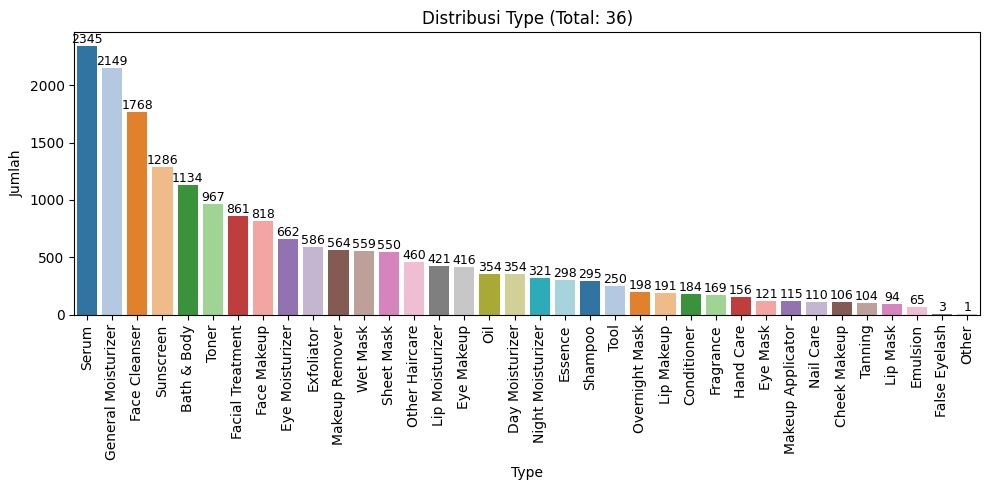

In [8]:
counts_type = df["type"].value_counts()
jumlah_type = df["type"].nunique()

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=counts_type.index,
    y=counts_type.values,
    palette="tab20"
)

plt.xticks(rotation=90)
plt.title(f"Distribusi Type (Total: {jumlah_type})")
plt.xlabel("Type")
plt.ylabel("Jumlah")

# 🔽 tambahkan nominal di atas bar
for i, v in enumerate(counts_type.values):
    ax.text(
        i, 
        v, 
        str(v), 
        ha='center', 
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()


In [9]:
df_tool = df[df["type"].str.lower() == "tool"]

print("Jumlah baris dengan type 'Tool':", len(df_tool))
df_tool.head(250)

Jumlah baris dengan type 'Tool': 250


,brand,name,type,country,ingridients,afterUse
7076,Revlon,One Step Hair Dryer and Volumizer,Tool,Australia,Nonane,NaN
7430,Sephora Collection,Vegan Face Mask Application Brush,Tool,France,Synthetic Wax,May Worsen Oily Skin
7996,Gillette,Venus Deluxe Smooth Swirl Razor,Tool,United States,"Peg-7m,Peg-115m,Peg-100,Silica,Pentaerythrityl...","Brightening,Eczema"
9212,Rare Beauty,Liquid Touch Foundation Brush,Tool,NaN,Synthetic Wax,May Worsen Oily Skin
9873,Sol De Janeiro,SOL Yellow Wide Tooth Comb,Tool,United States,Neryl Acetate,NaN
...,...,...,...,...,...,...
15207,Estrid,The Razor Case - Space,Tool,Sweden,Silicon,NaN
15215,Fraîcheur Paris,Gua Sha Facial Massager - Rose Quartz,Tool,France,Quartz,NaN
15621,Herbivore,Rose Quartz Gua Sha,Tool,NaN,Quartz,NaN
17119,Tweezerman,Sole Smoother Antibacterial Callus Stone,Tool,United States,Ceramide 4,"Redness Reducing,Anti-Aging"


In [10]:
df_tool = df[df["type"].str.lower() == "other"]

print("Jumlah baris dengan type 'other':", len(df_tool))
df_tool.head()

Jumlah baris dengan type 'other': 1


,brand,name,type,country,ingridients,afterUse
2173,Cortizone-10,Maximum Strength 1% Hydrocortisone Anti-Itch C...,Other,United States,"Hydrocortisone 1%,Aloe Barbadensis Leaf Juice,...","May Worsen Oily Skin,Acne Trigger"


In [11]:
df.duplicated().sum()

np.int64(10)

In [12]:
df[df.duplicated(keep=False)]

,brand,name,type,country,ingridients,afterUse
1055,Shiseido,Treatment Softener Enriched,Toner,Japan,"Water,Dipropylene Glycol,Glycerin,Diglycerin,P...","Reduces Irritation,Reduces Large Pores,Brighte..."
1344,Shiseido,Treatment Softener Enriched,Toner,Japan,"Water,Dipropylene Glycol,Glycerin,Diglycerin,P...","Reduces Irritation,Reduces Large Pores,Brighte..."
6188,innisfree,Intensive Hydrating Cream with Green Tea Seed,General Moisturizer,South Korea,"Rosa Damascena Flower Water,Propanediol,Glycer...","Reduces Irritation,Brightening,Acne Trigger"
6787,innisfree,Intensive Hydrating Cream with Green Tea Seed,General Moisturizer,South Korea,"Rosa Damascena Flower Water,Propanediol,Glycer...","Reduces Irritation,Brightening,Acne Trigger"
7221,"EltaMD, Inc",Skin Recovery Essence Toner,Toner,United States,"Water,Propanediol,Biosaccharide Gum-1,Glycerin...","Reduces Large Pores,Drying,Irritating"
7371,"EltaMD, Inc",Skin Recovery Essence Toner,Toner,United States,"Water,Propanediol,Biosaccharide Gum-1,Glycerin...","Reduces Large Pores,Drying,Irritating"
7713,M.S Skincare,Kapha | Energizing Body Oil,Bath & Body,United States,"Helianthus Annuus Seed Oil,Sulfated Coconut Oi...","Redness Reducing,Anti-Aging,Scar Healing,Brigh..."
8457,M.S Skincare,Kapha | Energizing Body Oil,Bath & Body,United States,"Helianthus Annuus Seed Oil,Sulfated Coconut Oi...","Redness Reducing,Anti-Aging,Scar Healing,Brigh..."
8775,No7,Radiance+ 15% Vitamin C Serum,Serum,United Kingdom,"Water,3-O-Ethyl Ascorbic Acid,Propylene Glycol...","Redness Reducing,Skin Texture,Anti-Aging,Dark ..."
8830,No7,Radiance+ 15% Vitamin C Serum,Serum,United Kingdom,"Water,3-O-Ethyl Ascorbic Acid,Propylene Glycol...","Redness Reducing,Skin Texture,Anti-Aging,Dark ..."


In [13]:
df.isnull().sum()

brand             0
name              0
type             15
country        1832
ingridients     319
afterUse       1524
dtype: int64

In [14]:
df[df['type'].isna()]

,brand,name,type,country,ingridients,afterUse
277,Yves Rocher,Anti-Aging After Sun Care,NaN,France,"Water,Glycerin,Methylpropanediol,Brassica Camp...","Reduces Irritation,Brightening,May Worsen Oily..."
1015,Espoir,Water Splash Sun Cream SPF50+PA+++,NaN,South Korea,"Rosa Damascena Flower Water,Butylene Glycol,C1...","Redness Reducing,Brightening,May Worsen Oily S..."
4824,Honeybee Gardens,Sunny Sport Spray Natural Sunscreen SPF 30 Sce...,NaN,NaN,"Zinc Oxide 5%,Titanium Dioxide 8%,Aloe Barbade...","Reduces Irritation,Brightening,Acne Trigger"
4957,Origins,VITAZING SPF 15 Energy-Boosting Moisturizer,NaN,United States,"Water,Citrus Aurantium Amara Flower Water,Anth...","Hydrating,Redness Reducing,Skin Texture,Reduce..."
6008,Freeman,Melting Sugar Face Mask,NaN,United States,"Water,Glucose,Glycerin,Propylene Glycol,Peg/Pp...",NaN
11872,Babor,Phyto Moss Cream,NaN,United Kingdom,"Water,Macadamia Integrifolia Seed Oil,Cetearyl...","Redness Reducing,Reduces Irritation,Skin Textu..."
12706,MartiDerm,Platinum Night Renew,NaN,Spain,"Water,Propanediol,Glycolic Acid,Lactic Acid,So...","Good For Oily Skin,Skin Texture,Reduces Large ..."
13195,TONYMOLY,Inkey Library Collagen Serum,NaN,South Korea,"Water,Chondrus Crispus Powder,Pentylene Glycol...","Redness Reducing,Anti-Aging,Scar Healing,Brigh..."
13552,Taro,Adapalene 0.3% Gel,NaN,United States,"Adapalene,Carbon,Disodium EDTA,Methylparaben,P...","Anti-Aging,Acne Fighting,Irritating"
14064,Somethinc,Revive Potion 3% Arbutin + Bakuchiol,NaN,Indonesia,"Oryza Sativa Bran Water,Alpha-Arbutin,Polyglyc...","Reduces Large Pores,Anti-Aging,Dark Spots,Scar..."


In [15]:
df[df['country'].isna()]

,brand,name,type,country,ingridients,afterUse
17,Anna Sui,Liquid Foundation,Face Makeup,NaN,"Water,Cyclomethicone,Ethylhexyl Methoxycinnama...","Drying,Acne Trigger,Irritating,Rosacea,Eczema"
98,Esfolio,Rose Essence Mask Sheet,Sheet Mask,NaN,"Water,Glycerin,Alcohol,Peg/Ppg-17/6 Copolymer,...",Rosacea
105,Elizabeth Arden,Eight Hour® Cream Sun Defense for Face SPF 50 ...,Sunscreen,NaN,"Ethylhexyl Methoxycinnamate 7.4%,Water 5%,C12-...","Anti-Aging,Scar Healing,Brightening,Irritating..."
108,Mielle Organics,Babassu Conditioning Sulfate-Free Shampoo,Shampoo,NaN,"Water,Decyl Glucoside,Cocamidopropylamine Oxid...","Reduces Large Pores,Drying,Irritating,Eczema"
113,StriVectin,Peptight™ Tightening Neck Serum Roller,Serum,NaN,"Water,Glycerin,C12-15 Alkyl Benzoate,Pentaeryt...","Anti-Aging,Scar Healing,Brightening,Drying,Acn..."
...,...,...,...,...,...,...
18883,Garden of Wisdom,Vitamin C Serum 23% + Ferulic Acid,Serum,NaN,"Water,Ascorbic Acid 23%,C16-17 Alkyl Benzoate,...","Good For Oily Skin,Redness Reducing,Reduces Ir..."
18919,Wander Beauty,Sight C-er Vitamin C Concentrate,Serum,NaN,"Water,Terminalia Ferdinandiana Fruit Extract,P...","Good For Oily Skin,Redness Reducing,Skin Textu..."
18986,Alpha-H,Vitamin B Serum with Niacinamide,Serum,NaN,"Water,Glycerin,Niacinamide,Methyl Gluceth-20,S...","Good For Oily Skin,Redness Reducing,Reduces Ir..."
19004,heimish,All Clean Balm,Makeup Remover,NaN,"Ethylhexyl Palmitate,Cetyl Ethylhexanoate,Peg-...","Good For Oily Skin,Brightening,Acne Trigger"


In [16]:
df[df['ingridients'].isna()]

,brand,name,type,country,ingridients,afterUse
10164,The Saem,St. Herb Micro Whip Foam,Face Cleanser,South Korea,NaN,NaN
10172,Tangle Teezer,Fine Mist Spray Bottle - Pink,Tool,United Kingdom,NaN,NaN
10173,Sephora Collection,Massager Globes for Eyes and Face,Tool,France,NaN,NaN
10178,Mizuho,KP-3 Portable Eyeshadow Brush (Pink),Makeup Applicator,Japan,NaN,NaN
10180,Tangle Teezer,Large Ultimate Detangler Hairbrush - Pebble Gr...,Tool,United Kingdom,NaN,NaN
...,...,...,...,...,...,...
14715,Flamingo,5-Blade Razors for Women - Sage,Tool,United States,NaN,NaN
14717,Amika,High Tide Deep Waver,Tool,United States,NaN,NaN
14895,The Original Makeup Eraser,The Original MakeUp Eraser® Makeup Remover Cloth,Makeup Remover,United States,NaN,NaN
15058,Avril,Konjac Sponge,Tool,France,NaN,NaN


In [17]:
df[df['afterUse'].isna()]

,brand,name,type,country,ingridients,afterUse
63,Armani Beauty,Luminous Silk Perfect Glow Flawless Oil-Free F...,Face Makeup,Italy,"Water,Cyclopentasiloxane,Glycerin,Isododecane,...",NaN
132,Lancôme,Tonique Douceur Softening Hydrating Toner with...,Toner,France,"Water,Glycerin,Sodium Citrate,Ci 42090,Ci 1470...",NaN
216,Armani Beauty,Luminous Silk Foundation,Face Makeup,Italy,"Water,Cyclopentasiloxane,Glycerin,Isododecane,...",NaN
431,L'Oreal,Revitalift Hyaluronic Acid Face Toner,Toner,France,"Water,Glycerin,Disodium EDTA,Sodium Citrate,So...",NaN
490,moshi moshi mind,Mind Hand Sanitizer 70% Ethanol,Hand Care,Denmark,"Alcohol Denat.,Water,Polyacrylate Crosspolymer...",NaN
...,...,...,...,...,...,...
18775,The Ordinary,100% Organic Cold-Pressed Rose Hip Seed Oil,Oil,Canada,Rosa Canina Seed Oil,NaN
18940,Hada Labo,Gokujyun Hyaluronic Acid Lotion,Toner,Japan,"Water,Butylene Glycol,Glycerin,Ppg-10 Methyl G...",NaN
18981,La Roche-Posay,Thermal Spring Water,Facial Treatment,France,Water,NaN
19024,Aveeno,Calm + Restore Nourishing Oat Cleanser For Sen...,Face Cleanser,United States,"Water,Glycerin,Butylene Glycol,Avena Sativa Ke...",NaN


# DATA PREPARATION

### Mengatasi data duplicated

In [18]:
before = len(df)
df = df.drop_duplicates()
after = len(df)

print("Jumlah duplikat terhapus:", before - after)

Jumlah duplikat terhapus: 10


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19040 entries, 0 to 19049
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   brand        19040 non-null  object
 1   name         19040 non-null  object
 2   type         19025 non-null  object
 3   country      17209 non-null  object
 4   ingridients  18721 non-null  object
 5   afterUse     17517 non-null  object
dtypes: object(6)
memory usage: 1.0+ MB


### Menghapus baris yang memiliki type 'tool'

In [21]:
# Hapus semua baris-type "Tool"
df = df[df["type"].str.lower() != "tool"]

# Reset index (opsional, tapi rapi)
df = df.reset_index(drop=True)

print("Selesai.\nJumlah data setelah penghapusan:", len(df))


Selesai.
Jumlah data setelah penghapusan: 18790


In [22]:
df.isnull().sum()

brand             0
name              0
type             15
country        1811
ingridients     137
afterUse       1283
dtype: int64

### Mengatasi missing value

In [23]:
df['country'] = df['country'].fillna("Unknown")

In [24]:
df['type'] = df['type'].fillna("Unknown")

In [25]:
df = df.dropna(subset=['ingridients','afterUse'])

In [26]:
df.isnull().sum()

brand          0
name           0
type           0
country        0
ingridients    0
afterUse       0
dtype: int64

In [27]:
df = df.reset_index(drop=True)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17507 entries, 0 to 17506
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   brand        17507 non-null  object
 1   name         17507 non-null  object
 2   type         17507 non-null  object
 3   country      17507 non-null  object
 4   ingridients  17507 non-null  object
 5   afterUse     17507 non-null  object
dtypes: object(6)
memory usage: 820.8+ KB


# TEKS CLEANING

In [29]:
import re
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\luthf\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [30]:
text_columns = ['brand','name','type','country','ingridients']

df[text_columns] = df[text_columns].astype(str)

In [31]:
def case_folding(text):
    return text.lower()

for col in text_columns:
    df[col] = df[col].apply(case_folding)

df.head()

,brand,name,type,country,ingridients,afterUse
0,the ordinary,glycolic acid 7% toning solution,toner,canada,"water,glycolic acid,rosa damascena flower wate...","Good For Oily Skin,Skin Texture,Reduces Large ..."
1,la roche-posay,toleriane hydrating gentle face cleanser,face cleanser,france,"water,glycerin,pentaerythrityl tetraethylhexan...","Good For Oily Skin,Redness Reducing,Reduces Ir..."
2,the ordinary,niacinamide 10% + zinc 1%,facial treatment,canada,"water,niacinamide,pentylene glycol,zinc pca,di...","Good For Oily Skin,Redness Reducing,Acne Fight..."
3,youth to the people,superfood antioxidant cleanser,face cleanser,united states,"water,cocamidopropyl hydroxysultaine,sodium co...","Redness Reducing,Reduces Irritation,Skin Textu..."
4,cosrx,low ph good morning gel cleanser,face cleanser,south korea,"water,cocamidopropyl betaine,sodium lauroyl me...","Good For Oily Skin,Reduces Irritation,Reduces ..."


# LABELLING

mengubah text menjadi list pada afterUse

In [32]:
df['afterUse']

0        Good For Oily Skin,Skin Texture,Reduces Large ...
1        Good For Oily Skin,Redness Reducing,Reduces Ir...
2        Good For Oily Skin,Redness Reducing,Acne Fight...
3        Redness Reducing,Reduces Irritation,Skin Textu...
4        Good For Oily Skin,Reduces Irritation,Reduces ...
                               ...                        
17502    Redness Reducing,Anti-Aging,Scar Healing,Brigh...
17503    Good For Oily Skin,Redness Reducing,Reduces Ir...
17504    Good For Oily Skin,Redness Reducing,Anti-Aging...
17505    Good For Oily Skin,Reduces Irritation,Skin Tex...
17506                                     Redness Reducing
Name: afterUse, Length: 17507, dtype: object

In [33]:
def split_effects(x):
    if pd.isna(x):
        return []

    x = str(x).strip().lower()
    if x == "":
        return []
    return [e.strip() for e in x.split(",")]

df["afterUse"] = df["afterUse"].apply(split_effects)

In [34]:
df['afterUse']

0        [good for oily skin, skin texture, reduces lar...
1        [good for oily skin, redness reducing, reduces...
2        [good for oily skin, redness reducing, acne fi...
3        [redness reducing, reduces irritation, skin te...
4        [good for oily skin, reduces irritation, reduc...
                               ...                        
17502    [redness reducing, anti-aging, scar healing, b...
17503    [good for oily skin, redness reducing, reduces...
17504    [good for oily skin, redness reducing, anti-ag...
17505    [good for oily skin, reduces irritation, skin ...
17506                                   [redness reducing]
Name: afterUse, Length: 17507, dtype: object

In [35]:
df.head()

,brand,name,type,country,ingridients,afterUse
0,the ordinary,glycolic acid 7% toning solution,toner,canada,"water,glycolic acid,rosa damascena flower wate...","[good for oily skin, skin texture, reduces lar..."
1,la roche-posay,toleriane hydrating gentle face cleanser,face cleanser,france,"water,glycerin,pentaerythrityl tetraethylhexan...","[good for oily skin, redness reducing, reduces..."
2,the ordinary,niacinamide 10% + zinc 1%,facial treatment,canada,"water,niacinamide,pentylene glycol,zinc pca,di...","[good for oily skin, redness reducing, acne fi..."
3,youth to the people,superfood antioxidant cleanser,face cleanser,united states,"water,cocamidopropyl hydroxysultaine,sodium co...","[redness reducing, reduces irritation, skin te..."
4,cosrx,low ph good morning gel cleanser,face cleanser,south korea,"water,cocamidopropyl betaine,sodium lauroyl me...","[good for oily skin, reduces irritation, reduc..."


Melihat afterUse

In [36]:
# ======== 2️⃣ Lihat semua efek unik =========
all_effects = sorted(set([e for sublist in df['afterUse'] for e in sublist]))
print(f"\nJumlah total efek unik : {len(all_effects)}")
print("Daftar efek unik :")
for i, effect in enumerate(all_effects):
    print(f"{i+1}. {effect}")


Jumlah total efek unik : 17
Daftar efek unik :
1. acne fighting
2. acne trigger
3. anti-aging
4. brightening
5. dark spots
6. drying
7. eczema
8. good for oily skin
9. hydrating
10. irritating
11. may worsen oily skin
12. redness reducing
13. reduces irritation
14. reduces large pores
15. rosacea
16. scar healing
17. skin texture


MultiLabelBinarizer

In [37]:
from sklearn.preprocessing import MultiLabelBinarizer

# ======== 6️⃣ Ubah efek bersih menjadi kolom biner =========
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df['afterUse'])


label_df = pd.DataFrame(Y, columns=mlb.classes_, index=df.index)
df = pd.concat([df, label_df], axis=1)

print("\n=== Contoh hasil akhir DataFrame (kolom label sudah ditambah) ===")
df.head()


=== Contoh hasil akhir DataFrame (kolom label sudah ditambah) ===


,brand,name,type,country,ingridients,afterUse,acne fighting,acne trigger,anti-aging,brightening,...,good for oily skin,hydrating,irritating,may worsen oily skin,redness reducing,reduces irritation,reduces large pores,rosacea,scar healing,skin texture
0,the ordinary,glycolic acid 7% toning solution,toner,canada,"water,glycolic acid,rosa damascena flower wate...","[good for oily skin, skin texture, reduces lar...",0,1,1,1,...,1,0,1,0,0,0,1,1,0,1
1,la roche-posay,toleriane hydrating gentle face cleanser,face cleanser,france,"water,glycerin,pentaerythrityl tetraethylhexan...","[good for oily skin, redness reducing, reduces...",1,1,1,1,...,1,0,0,0,1,1,0,0,0,0
2,the ordinary,niacinamide 10% + zinc 1%,facial treatment,canada,"water,niacinamide,pentylene glycol,zinc pca,di...","[good for oily skin, redness reducing, acne fi...",1,0,0,1,...,1,0,1,0,1,0,0,0,0,0
3,youth to the people,superfood antioxidant cleanser,face cleanser,united states,"water,cocamidopropyl hydroxysultaine,sodium co...","[redness reducing, reduces irritation, skin te...",0,1,1,1,...,0,0,1,0,1,1,1,0,0,1
4,cosrx,low ph good morning gel cleanser,face cleanser,south korea,"water,cocamidopropyl betaine,sodium lauroyl me...","[good for oily skin, reduces irritation, reduc...",0,1,0,0,...,1,0,1,0,0,1,1,0,0,0


In [38]:
label_cols = df.columns[6:]  # kolom label
df[['name'] + list(label_cols)].head()

,name,acne fighting,acne trigger,anti-aging,brightening,dark spots,drying,eczema,good for oily skin,hydrating,irritating,may worsen oily skin,redness reducing,reduces irritation,reduces large pores,rosacea,scar healing,skin texture
0,glycolic acid 7% toning solution,0,1,1,1,1,1,0,1,0,1,0,0,0,1,1,0,1
1,toleriane hydrating gentle face cleanser,1,1,1,1,0,1,0,1,0,0,0,1,1,0,0,0,0
2,niacinamide 10% + zinc 1%,1,0,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0
3,superfood antioxidant cleanser,0,1,1,1,1,1,0,0,0,1,0,1,1,1,0,0,1
4,low ph good morning gel cleanser,0,1,0,0,0,1,0,1,0,1,0,0,1,1,0,0,0


In [39]:
label_names = mlb.classes_

In [40]:
print(Y.shape, mlb.classes_)

(17507, 17) ['acne fighting' 'acne trigger' 'anti-aging' 'brightening' 'dark spots'
 'drying' 'eczema' 'good for oily skin' 'hydrating' 'irritating'
 'may worsen oily skin' 'redness reducing' 'reduces irritation'
 'reduces large pores' 'rosacea' 'scar healing' 'skin texture']


# DISTRIBUSI LABEL

Distribusi Label:
brightening             11958
irritating              10495
anti-aging               9223
acne trigger             7901
drying                   7806
redness reducing         7076
reduces large pores      6448
eczema                   6333
scar healing             6120
good for oily skin       6076
reduces irritation       5858
acne fighting            4870
skin texture             4700
rosacea                  4396
may worsen oily skin     4282
dark spots               4244
hydrating                2531
dtype: int64


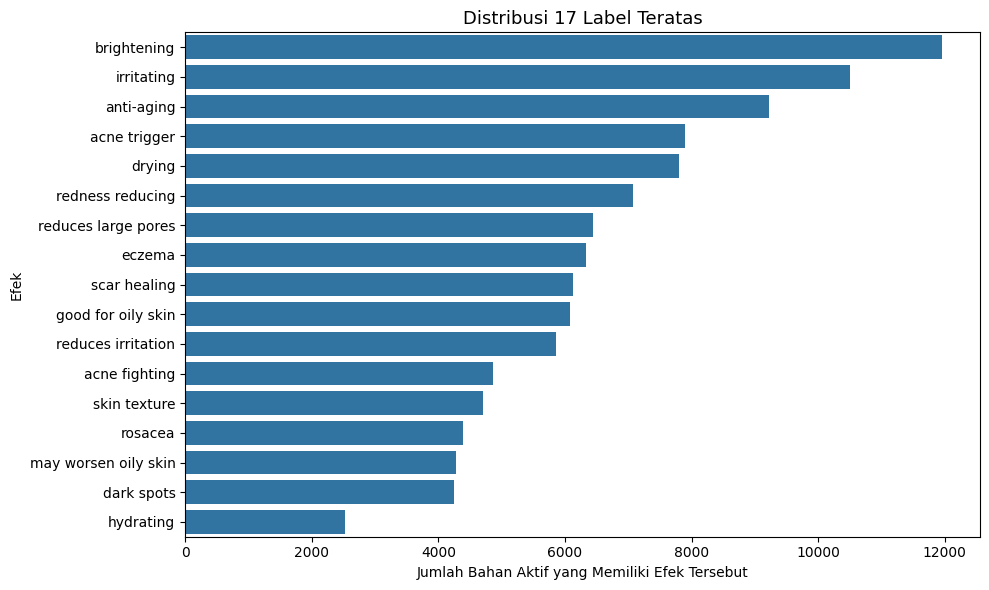

In [41]:
# Menghitung jumlah kemunculan tiap label
label_counts = label_df.sum().sort_values(ascending=False)

# Menampilkan distribusi label
print("Distribusi Label:")
print(label_counts)

# Visualisasi distribusi label
plt.figure(figsize=(10,6))
sns.barplot(x=label_counts.head(20).values, y=label_counts.head(20).index)
plt.title("Distribusi 17 Label Teratas", fontsize=13)
plt.xlabel("Jumlah Bahan Aktif yang Memiliki Efek Tersebut")
plt.ylabel("Efek")
plt.tight_layout()
plt.show()

Distribusi Kelas Tiap Label (0 dan 1):
                          0      1
acne fighting         12637   4870
acne trigger           9606   7901
anti-aging             8284   9223
brightening            5549  11958
dark spots            13263   4244
drying                 9701   7806
eczema                11174   6333
good for oily skin    11431   6076
hydrating             14976   2531
irritating             7012  10495
may worsen oily skin  13225   4282
redness reducing      10431   7076
reduces irritation    11649   5858
reduces large pores   11059   6448
rosacea               13111   4396
scar healing          11387   6120
skin texture          12807   4700


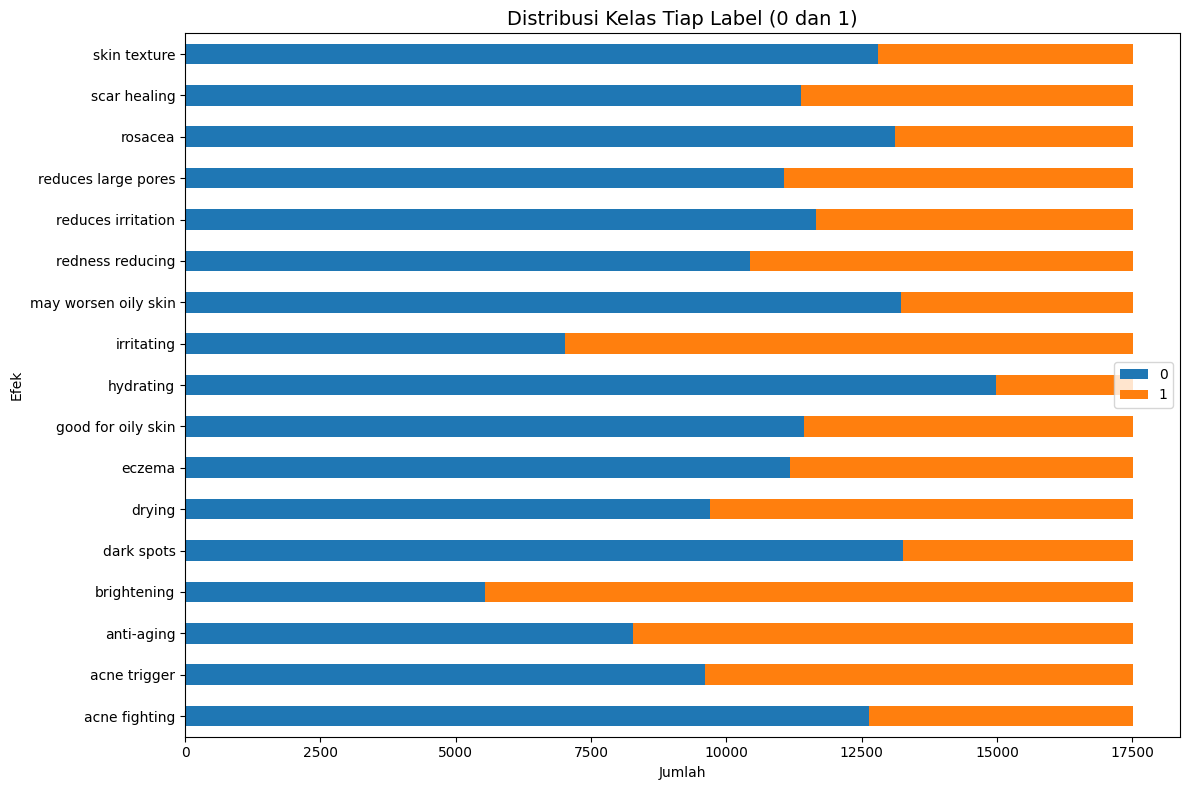

In [42]:
# Menghitung jumlah kelas 0 dan 1 untuk tiap label
label_zeros_ones = label_df.apply(pd.Series.value_counts, axis=0).T.fillna(0)

# Menampilkan distribusi kelas (0 dan 1) untuk tiap label
print("Distribusi Kelas Tiap Label (0 dan 1):")
print(label_zeros_ones)

# Visualisasi distribusi kelas untuk tiap label
label_zeros_ones.plot(kind='barh', stacked=True, figsize=(12,8))
plt.title("Distribusi Kelas Tiap Label (0 dan 1)", fontsize=14)
plt.xlabel("Jumlah")
plt.ylabel("Efek")
plt.tight_layout()
plt.show()


In [43]:
df.describe()

,acne fighting,acne trigger,anti-aging,brightening,dark spots,drying,eczema,good for oily skin,hydrating,irritating,may worsen oily skin,redness reducing,reduces irritation,reduces large pores,rosacea,scar healing,skin texture
count,17507.000000,17507.000000,17507.000000,17507.000000,17507.000000,17507.000000,17507.000000,17507.000000,17507.000000,17507.000000,17507.000000,17507.000000,17507.000000,17507.00000,17507.000000,17507.000000,17507.000000
mean,0.278174,0.451305,0.526818,0.683041,0.242417,0.445879,0.361741,0.347061,0.144571,0.599474,0.244588,0.404181,0.334609,0.36831,0.251100,0.349574,0.268464
std,0.448113,0.497637,0.499295,0.465305,0.428558,0.497076,0.480518,0.476049,0.351678,0.490019,0.429855,0.490747,0.471867,0.48236,0.433658,0.476849,0.443173
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000


# EKSTRAKSI FITUR

In [44]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

ONE HOT ENCODING KOLOM BRAND, TYPE, COUNTRY

In [45]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

X_cat = ohe.fit_transform(
    df[['brand', 'type', 'country']]
)
feature_names = ohe.get_feature_names_out(['brand', 'type', 'country'])

In [46]:
from collections import defaultdict

features_per_column = defaultdict(list)
ohe_feature_names = ohe.get_feature_names_out()

for feat in ohe_feature_names:
    col_name = feat.split('_')[0]   # name, brand, type, country
    features_per_column[col_name].append(feat)

In [47]:
for col, feats in features_per_column.items():
    print(f"\nKolom: {col}")
    print(f"Jumlah fitur: {len(feats)}")
    print(feats[:5])  # tampilkan 10 pertama saja



Kolom: brand
Jumlah fitur: 2123
['brand_# give them lala beauty', 'brand_(malin+goetz)', 'brand_/kili•g/', 'brand_100% pure', 'brand_111medco']

Kolom: type
Jumlah fitur: 36
['type_bath & body', 'type_cheek makeup', 'type_conditioner', 'type_day moisturizer', 'type_emulsion']

Kolom: country
Jumlah fitur: 70
['country_american samoa', 'country_argentina', 'country_australia', 'country_austria', 'country_bangladesh']


TF-IDF KOLOM INGREDIENTS

In [48]:
# TF-IDF untuk ingredients
tfidf_ing = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,4),
    min_df=2,
    max_df=0.85,
    stop_words='english'
)
X_tfidf_ing = tfidf_ing.fit_transform(df['ingridients'])
feature_names_ing = tfidf_ing.get_feature_names_out()

In [49]:
print("All Feature Names Ingredients:")
for feature in feature_names_ing:
    print(feature)

All Feature Names Ingredients:
10
10 15
10 15 crosspolymer
10 dimethicone
10 laurate
10 myristate
10 oleate
10 stearate
100
100 stearate
100 stearate glyceryl
100 stearate glyceryl stearate
11
12
12 alkane
12 dimethicone
120
120 methyl
120 methyl glucose
120 methyl glucose dioleate
13
14
14 isoparaffin
14 pareth
14 pareth 12
14700
14700 ci
15
15 alkane
15 alkyl
15 alkyl benzoate
15 crosspolymer
15 stearyl
15 stearyl ether
150
150 distearate
15850
15850 ci
15985
15985 ci
16
16 alcohols
16 olefin
16 olefin sulfonate
16035
16035 ci
17
17 copolymer
17200
17200 ci
18
18 18
18 18 dimethicone
18 dimethicone
18 methyl
18 methyl ether
18 methyl ether dimethyl
18 triglycerides
19
19 alkane
19140
19140 ci
19140 ci 15985
19140 ci 42090
20
20 alkyl
20 alkyl glucoside
20 glyceryl
20 glyceryl triisostearate
20 peg
20 phenoxyethanol
20 sodium
20 sorbitan
21
22
22 alcohols
22 alkyl
23
24
25
25 methacrylate
26
26 buteth
26 buteth 26
26 peg
30
30 alkyl
30 alkyl acrylate
30 alkyl acrylate crosspolymer
30 

In [50]:
# jumlah fitur hasil TF-IDF
jumlah_fitur_tfidf = X_tfidf_ing.shape[1]
print("Jumlah fitur baru hasil TF-IDF:", jumlah_fitur_tfidf)

Jumlah fitur baru hasil TF-IDF: 5000


In [51]:
tfidf_df = pd.DataFrame(X_tfidf_ing.toarray(), columns=feature_names_ing)
tfidf_df.iloc[0].sort_values(ascending=False).head(10)

pca sodium                  0.218326
flower water                0.161143
pca                         0.141065
lanceolata                  0.127509
valine isoleucine           0.127269
pca sodium lactate          0.127031
glycol potassium sorbate    0.124799
fruit leaf extract          0.123175
proline threonine           0.121674
centaurea                   0.120963
Name: 0, dtype: float64

In [52]:
# Hitung skor TF-IDF total
tfidf_scores = np.asarray(X_tfidf_ing.sum(axis=0)).ravel()

# Ambil top-N terms
top_n = 10
top_indices = tfidf_scores.argsort()[::-1][:top_n]

top_terms = pd.DataFrame({
    "Ingredient": [feature_names_ing[i] for i in top_indices],
    "TF-IDF Score": tfidf_scores[top_indices]
})

top_terms

,Ingredient,TF-IDF Score
0,extract,1373.854846
1,oil,933.166777
2,sodium,866.066682
3,acid,768.319531
4,glycol,625.711447
5,seed,555.605162
6,ci,515.517199
7,leaf,514.230782
8,alcohol,488.024859
9,water,467.307128


TF-IDF KOLOM NAME

In [53]:
# TF-IDF untuk name
tfidf_name = TfidfVectorizer(
    max_features=5000,  # teks lebih pendek
    ngram_range=(1,4),
    min_df=2,
    max_df=0.85,
    stop_words='english'
)
X_tfidf_name = tfidf_name.fit_transform(df['name'])
feature_names_name = tfidf_name.get_feature_names_out()

In [54]:
print("All Feature Names:")
for feature in feature_names_name:
    print(feature)

All Feature Names:
001
01
02
025
03
04
05
06
10
10 aha
10 azelaic
10 azelaic acid
10 benzoyl peroxide
10 formula
10 glycolic
10 miracle
10 miracle leave
10 niacinamide
10 pure
10 serum
10 vitamin
100
100 mineral
100 mineral lotion
100 mineral lotion spf
100 natural
1000
1025
1025 dokdo
11
110
12
14
15
15 vitamin
16
17
20
20 vitamin
2021
21
22
23
24
24 hour
24h
24hr
24k
24k gold
25
2x
30
30 days
30 days miracle
30 face
30 mineral
30 pa
30 sensitive
30 sunscreen
3000
33
35
35 pa
36
360
365
3d
40
40 pa
400
42
45
46
50
50 face
50 fragrance
50 fragrance free
50 pa
50 sensitive
50 sunscreen
50 tinted
55
5x
60
70
75
80
92
99
abeille
abeille royale
absolute
absorbing
ac
ac collection
acai
ace
acerola
acid
acid 10
acid acne
acid acne treatment
acid aha
acid anti
acid body
acid cleanser
acid cleansing
acid cream
acid exfoliating
acid eye
acid face
acid facial
acid facial serum
acid gel
acid hydrating
acid moisturizer
acid niacinamide
acid night
acid peel
acid pore
acid resurfacing
acid serum
aci

In [55]:
# jumlah fitur hasil TF-IDF
jumlah_fitur_name = X_tfidf_name.shape[1]
print("Jumlah fitur name baru hasil TF-IDF:", jumlah_fitur_name)

Jumlah fitur name baru hasil TF-IDF: 5000


In [56]:
tfidf_df = pd.DataFrame(X_tfidf_name.toarray(), columns=feature_names_name)
tfidf_df.iloc[0].sort_values(ascending=False).head(5)

toning           0.504671
glycolic acid    0.496830
glycolic         0.449064
solution         0.435387
acid             0.327484
Name: 0, dtype: float64

In [57]:
term_importance = np.asarray(X_tfidf_name.sum(axis=0)).ravel()

top_indices = term_importance.argsort()[::-1][:5]

top_terms = pd.Series(
    term_importance[top_indices],
    index=[feature_names_name[i] for i in top_indices]
)

print("Top 5 most important terms based on TF-IDFIngredients score:")
print(top_terms)

Top 5 most important terms based on TF-IDFIngredients score:
cream       536.353319
serum       474.831357
mask        314.838836
cleanser    278.557301
oil         260.975641
dtype: float64


# SELEKSI FITUR

In [58]:
import numpy as np
from sklearn.feature_selection import chi2, mutual_info_classif

In [59]:
mi_scores = []

for label_idx in range(Y.shape[1]):
    mi = mutual_info_classif(
        X_cat,
        Y[:, label_idx],
        discrete_features=True,
        random_state=42
    )
    mi_scores.append(mi)

mi_scores = np.array(mi_scores)
mean_mi = mi_scores.mean(axis=0)

In [60]:
mi_df = pd.DataFrame({
    'Feature': feature_names,
    'MI_Score': mean_mi
})

In [61]:
mi_df['Main_Feature'] = mi_df['Feature'].apply(
    lambda x: x.split('_')[0]
)

summary_mi = (
    mi_df
    .groupby('Main_Feature')
    .agg(
        Mean_MI=('MI_Score', 'mean'),
        Max_MI=('MI_Score', 'max'),
        NonZero_Count=('MI_Score', lambda x: (x > 0).sum()),
        Total_Features=('MI_Score', 'count')
    )
    .reset_index()
)


In [62]:
summary_mi['NonZero_Ratio'] = (
    summary_mi['NonZero_Count'] / summary_mi['Total_Features']
)

summary_mi


,Main_Feature,Mean_MI,Max_MI,NonZero_Count,Total_Features,NonZero_Ratio
0,brand,0.000072,0.000868,2123,2123,1.0
1,country,0.000241,0.006969,70,70,1.0
2,type,0.001372,0.008012,36,36,1.0


In [63]:
mi_ing = []

for label_idx in range(Y.shape[1]):
    mi = mutual_info_classif(
        X_tfidf_ing,
        Y[:, label_idx],
        random_state=42
    )
    mi_ing.append(mi)

mi_ing = np.array(mi_ing).mean(axis=0)

print("Ingredients:")
print("Mean MI:", mi_ing.mean())
print("Non-zero ratio:", (mi_ing > 0).mean())

Ingredients:
Mean MI: 0.013571866516976127
Non-zero ratio: 1.0


In [64]:
mi_name = []

for label_idx in range(Y.shape[1]):
    mi = mutual_info_classif(
        X_tfidf_name,
        Y[:, label_idx],
        random_state=42
    )
    mi_name.append(mi)

mi_name = np.array(mi_name).mean(axis=0)

print("\nName:")
print("Mean MI:", mi_name.mean())
print("Non-zero ratio:", (mi_name > 0).mean())


Name:
Mean MI: 0.0007227470655448791
Non-zero ratio: 1.0


In [65]:
# Hitung Chi-Square per label
chi_scores_all = []

for label_idx in range(Y.shape[1]):
    chi_scores, _ = chi2(X_tfidf_ing, Y[:, label_idx])
    chi_scores_all.append(chi_scores)

chi_scores_all = np.array(chi_scores_all)

# Mean Chi-Square per fitur
chi_scores_mean = chi_scores_all.mean(axis=0)

# Threshold median
threshold = np.percentile(chi_scores_mean, 50)

# Seleksi fitur
selected_idx = np.where(chi_scores_mean >= threshold)[0]
X_ing_chi = X_tfidf_ing[:, selected_idx]

print("Threshold Chi-Square:", threshold)
print("Jumlah fitur awal:", X_tfidf_ing.shape[1])
print("Jumlah fitur setelah Chi-Square:", X_ing_chi.shape[1])

# DataFrame Chi-Square mean
chi_df = pd.DataFrame({
    'feature': feature_names_ing,
    'chi_square_mean': chi_scores_mean
})

# Fitur Chi-Square minimum
min_feature = chi_df.loc[chi_df['chi_square_mean'].idxmin()]

# Fitur Chi-Square maksimum
max_feature = chi_df.loc[chi_df['chi_square_mean'].idxmax()]

print("\nFitur dengan Chi-Square MEAN MINIMUM:")
print(min_feature)

print("\nFitur dengan Chi-Square MEAN MAKSIMUM:")
print(max_feature)

Threshold Chi-Square: 1.0033058923096188
Jumlah fitur awal: 5000
Jumlah fitur setelah Chi-Square: 2500

Fitur dengan Chi-Square MEAN MINIMUM:
feature            fragaria
chi_square_mean    0.050866
Name: 2203, dtype: object

Fitur dengan Chi-Square MEAN MAKSIMUM:
feature             glycolic
chi_square_mean    73.793436
Name: 2482, dtype: object


In [126]:
# Fitur yang lolos threshold Chi-Square
selected_features = np.array(feature_names_ing)[selected_idx]

In [66]:
print("Min Chi:", chi_scores_mean.min())
print("Max Chi:", chi_scores_mean.max())
print("Mean Chi:", chi_scores_mean.mean())

Min Chi: 0.050865915562700925
Max Chi: 73.79343584494232
Mean Chi: 2.109352231955915


# SPLITTING DATA

In [67]:
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X_ing_chi,
    Y,
    test_size=0.2,
    random_state=42
)

In [69]:
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

X_train : (14005, 2500)
y_train : (14005, 17)
X_test  : (3502, 2500)
y_test  : (3502, 17)


# MODEL XGBOOST

In [70]:
from xgboost import XGBClassifier
from skmultilearn.problem_transform import ClassifierChain,BinaryRelevance,LabelPowerset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
import time

## XGBOOST

In [71]:
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    max_depth=2,
    min_child_weight=5,
    learning_rate=0.03,
    n_estimators=400,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.5,
    random_state=42
)

### Classifier chain

In [72]:
cc_model = ClassifierChain(
    classifier=xgb_base
)

cc_model.fit(X_train, y_train)

,classifier,"XGBClassifier...ree=None, ...)"
,require_dense,"[True, True]"
,order,None
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None


In [73]:
br_model = BinaryRelevance(
    classifier=xgb_base
)
br_model.fit(X_train, y_train)

,classifier,"XGBClassifier...ree=None, ...)"
,require_dense,"[True, True]"
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None


In [74]:
lp_model = LabelPowerset(
    classifier=xgb_base
)
lp_model.fit(X_train, y_train)

,classifier,"XGBClassifier...ree=None, ...)"
,require_dense,"[True, True]"
,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None


In [76]:
y_pred_lp = lp_model.predict(X_test)
y_pred_cc = cc_model.predict(X_test)
y_pred_br = br_model.predict(X_test)

In [97]:
import pandas as pd
from sklearn.metrics import (
    classification_report,
    f1_score,
    hamming_loss,
    accuracy_score,
    precision_score,
    recall_score
)

results = []

def evaluate_multilabel_model(
    model,
    model_name,
    X_train,
    y_train,
    X_test,
    y_test,
    label_names
):

    print(f"\n===== Evaluation: {model_name} =====")

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    # classification report
    print("Classification Report (Test):")
    report = classification_report(
        y_test,
        y_pred_test,
        target_names=label_names,
        zero_division=0
    )
    print(report)

    # metrik global
    precision = precision_score(y_test, y_pred_test, average="micro", zero_division=0)
    recall = recall_score(y_test, y_pred_test, average="micro", zero_division=0)
    f1_micro = f1_score(y_test, y_pred_test, average="micro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred_test, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)
    h_loss = hamming_loss(y_test, y_pred_test)
    subset_acc = accuracy_score(y_test, y_pred_test)

    # cetak metrik utama
    print(f"Hamming Loss   : {h_loss:.2f}")
    print(f"Subset Accuracy: {subset_acc:.2f}")

    # simpan ke tabel komparasi
    results.append({
        "Model": model_name,
        "F1 Micro": f1_micro,
        "F1 Macro": f1_macro,
        "F1 Weighted": f1_weighted,
        "Precision": precision,
        "Recall": recall,
        "Hamming Loss": h_loss,
        "Subset Accuracy": subset_acc
    })


def show_results():
    df = pd.DataFrame(results)
    return df.round(2)

In [98]:
evaluate_multilabel_model(
    br_model,
    "Binary Relevance",
    X_train, y_train,
    X_test, y_test,
    mlb.classes_
)

evaluate_multilabel_model(
    cc_model,
    "Classifier Chain",
    X_train, y_train,
    X_test, y_test,
    mlb.classes_
)

evaluate_multilabel_model(
    lp_model,
    "Label Powerset",
    X_train, y_train,
    X_test, y_test,
    mlb.classes_
)



===== Evaluation: Binary Relevance =====
Classification Report (Test):
                      precision    recall  f1-score   support

       acne fighting       1.00      0.96      0.98       966
        acne trigger       0.97      0.92      0.94      1579
          anti-aging       0.88      0.96      0.92      1855
         brightening       0.99      0.98      0.99      2391
          dark spots       0.91      0.97      0.94       832
              drying       0.86      0.96      0.91      1532
              eczema       0.97      0.95      0.96      1276
  good for oily skin       0.97      0.97      0.97      1196
           hydrating       0.95      0.93      0.94       497
          irritating       0.87      0.96      0.91      2092
may worsen oily skin       0.97      0.95      0.96       856
    redness reducing       0.94      0.99      0.96      1425
  reduces irritation       0.96      0.96      0.96      1133
 reduces large pores       0.82      0.96      0.88      12

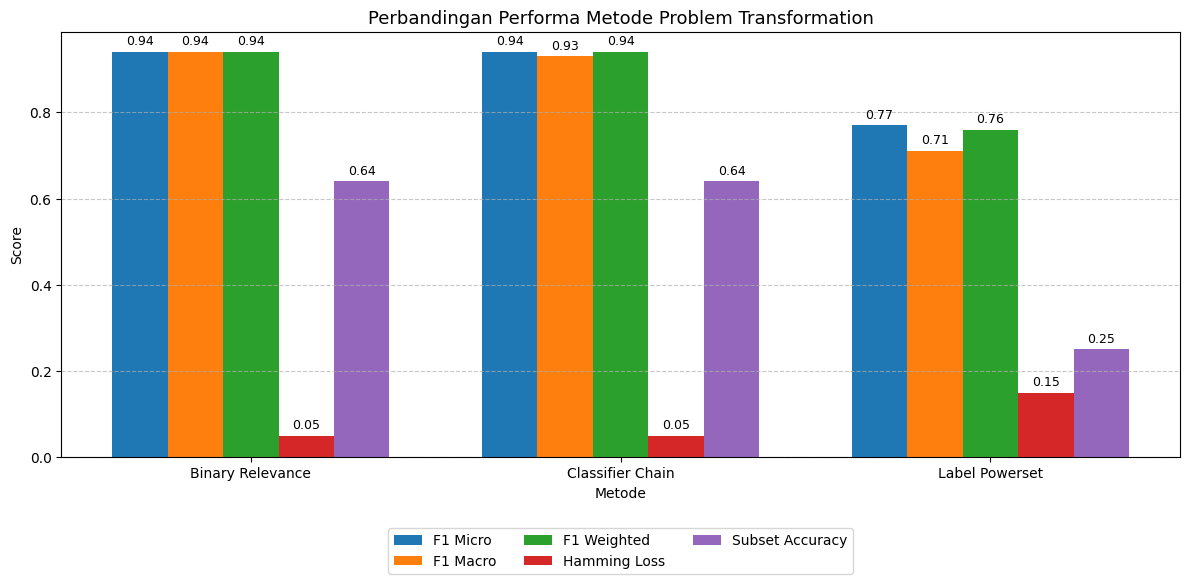

In [100]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ["Binary Relevance", "Classifier Chain", "Label Powerset"]

f1_micro = [0.94, 0.94, 0.77]
f1_macro = [0.94, 0.93, 0.71]
f1_weighted = [0.94, 0.94, 0.76]
hamming_loss = [0.05, 0.05, 0.15]
subset_acc = [0.64, 0.64, 0.25]

x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(12,6))
ax = plt.gca()

# Plot bar
bars1 = ax.bar(x - 2*width, f1_micro, width, label='F1 Micro')
bars2 = ax.bar(x - width, f1_macro, width, label='F1 Macro')
bars3 = ax.bar(x, f1_weighted, width, label='F1 Weighted')
bars4 = ax.bar(x + width, hamming_loss, width, label='Hamming Loss')
bars5 = ax.bar(x + 2*width, subset_acc, width, label='Subset Accuracy')

# Label
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Score")
ax.set_title("Perbandingan Performa Metode Problem Transformation", fontsize=13)
ax.set_xlabel("Metode")

# Fungsi untuk menampilkan angka di atas batang
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

# Tambahkan label ke semua bar
for bars in [bars1, bars2, bars3, bars4, bars5]:
    add_labels(bars)

# Legend di bawah
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

# Grid
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [101]:
def get_report_df(y_true, y_pred, label_names):
    report = classification_report(
        y_true,
        y_pred,
        target_names=label_names,
        output_dict=True,
        zero_division=0
    )
    return pd.DataFrame(report).T

In [102]:
df_br = get_report_df(y_test, y_pred_br, mlb.classes_)
df_cc = get_report_df(y_test, y_pred_cc, mlb.classes_)
df_lp = get_report_df(y_test, y_pred_lp, mlb.classes_)

In [103]:
def plot_multilabel_bar(df_report, label_names, title):

    metrics_df = df_report.loc[
        list(label_names),
        ["precision", "recall", "f1-score"]
    ]

    labels = metrics_df.index.tolist()
    precision = metrics_df["precision"].values
    recall = metrics_df["recall"].values
    f1 = metrics_df["f1-score"].values

    gap = 2.8
    bar_height = 0.6
    y = np.arange(len(labels)) * gap

    plt.figure(figsize=(12, 0.9 * len(labels)))  # grafik lebih tinggi

    plt.barh(y - bar_height, precision, height=bar_height, label="Precision")
    plt.barh(y, recall, height=bar_height, label="Recall")
    plt.barh(y + bar_height, f1, height=bar_height, label="F1-score")

    plt.yticks(y, labels, fontsize=11)
    plt.xlabel("Score", fontsize=12)
    plt.title(title, fontsize=14)
    plt.xlim(0, 1.05)

    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.03),
        ncol=3,
        fontsize=11
    )

    # angka di ujung batang
    for i in range(len(labels)):
        plt.text(precision[i] + 0.01, y[i] - bar_height, f"{precision[i]:.2f}", va="center", fontsize=10)
        plt.text(recall[i] + 0.01, y[i], f"{recall[i]:.2f}", va="center", fontsize=10)
        plt.text(f1[i] + 0.01, y[i] + bar_height, f"{f1[i]:.2f}", va="center", fontsize=10)

    plt.tight_layout()
    plt.show()

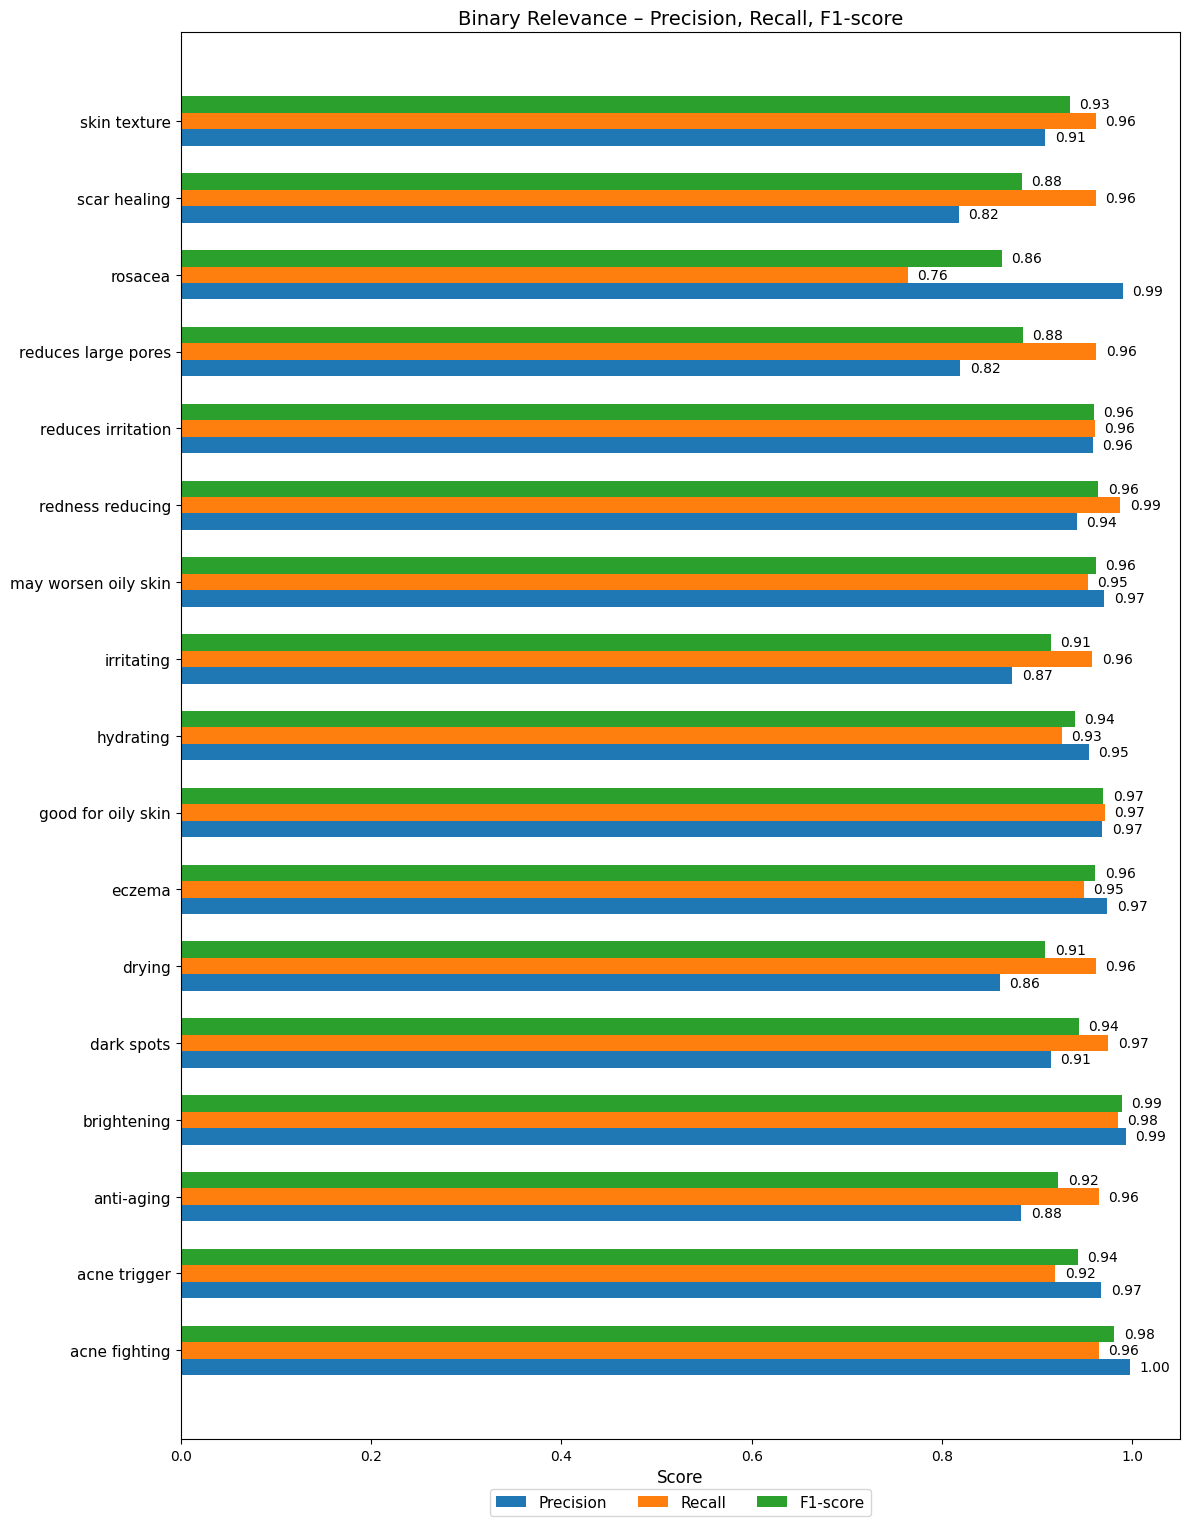

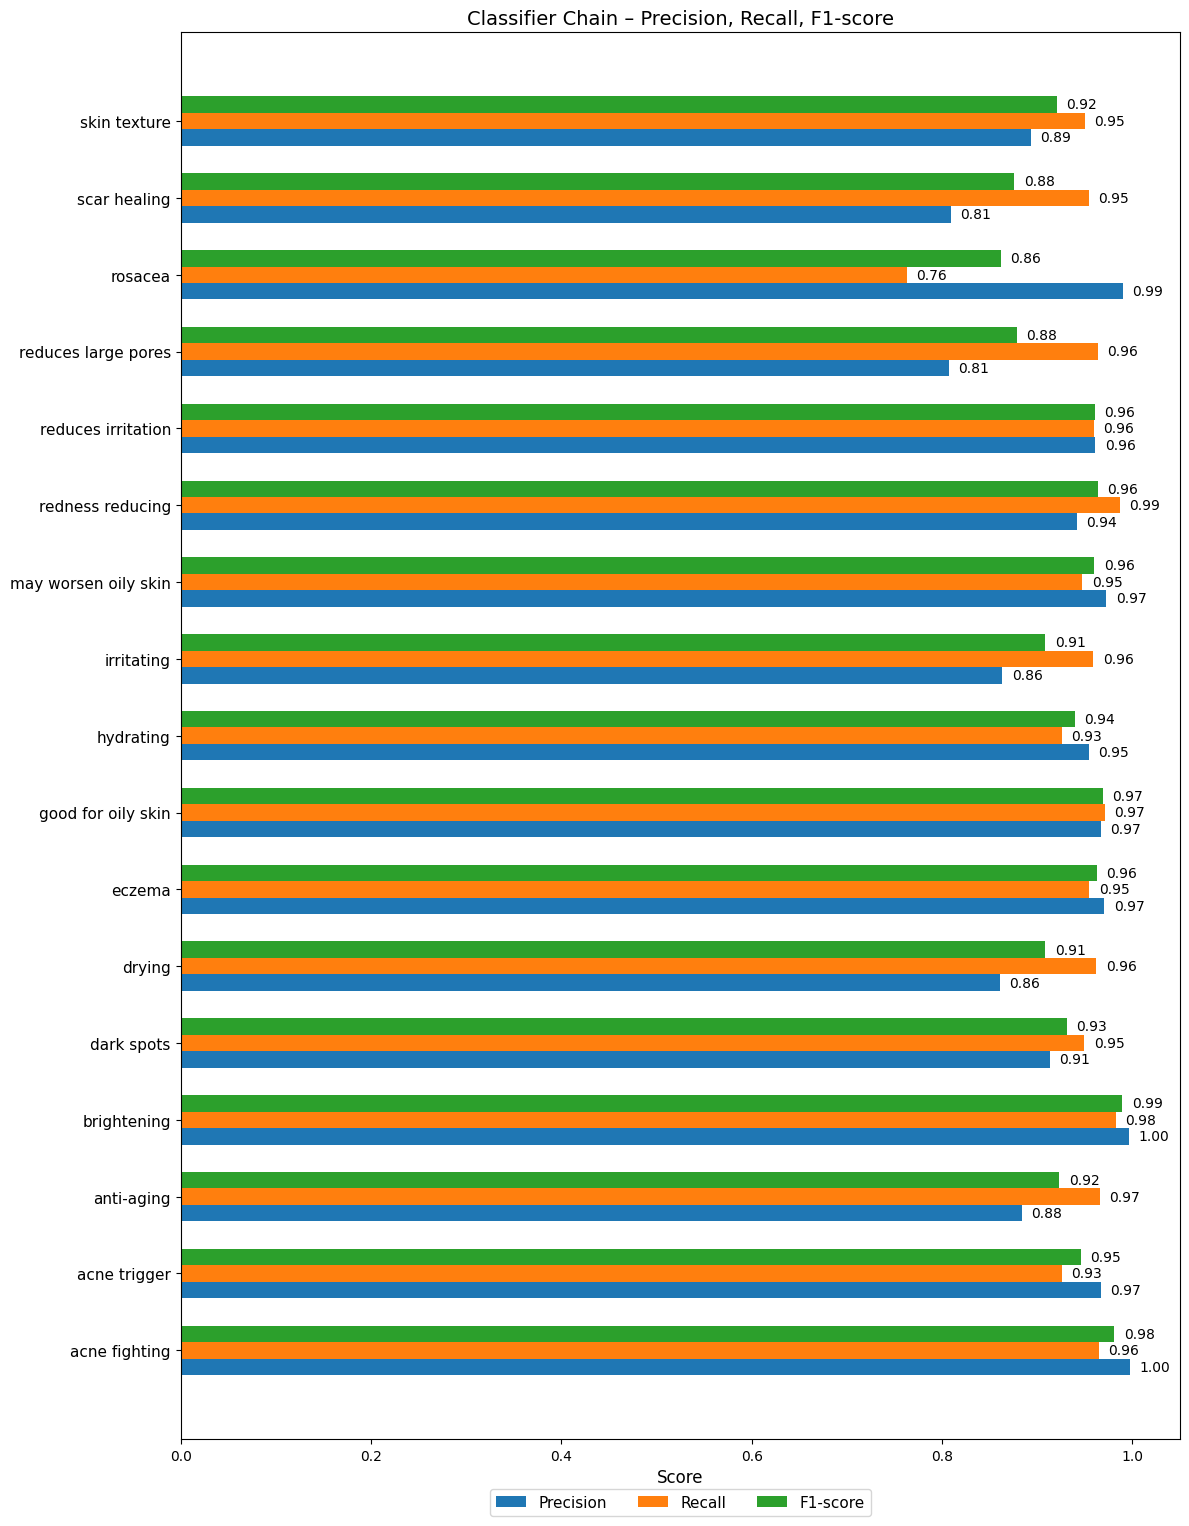

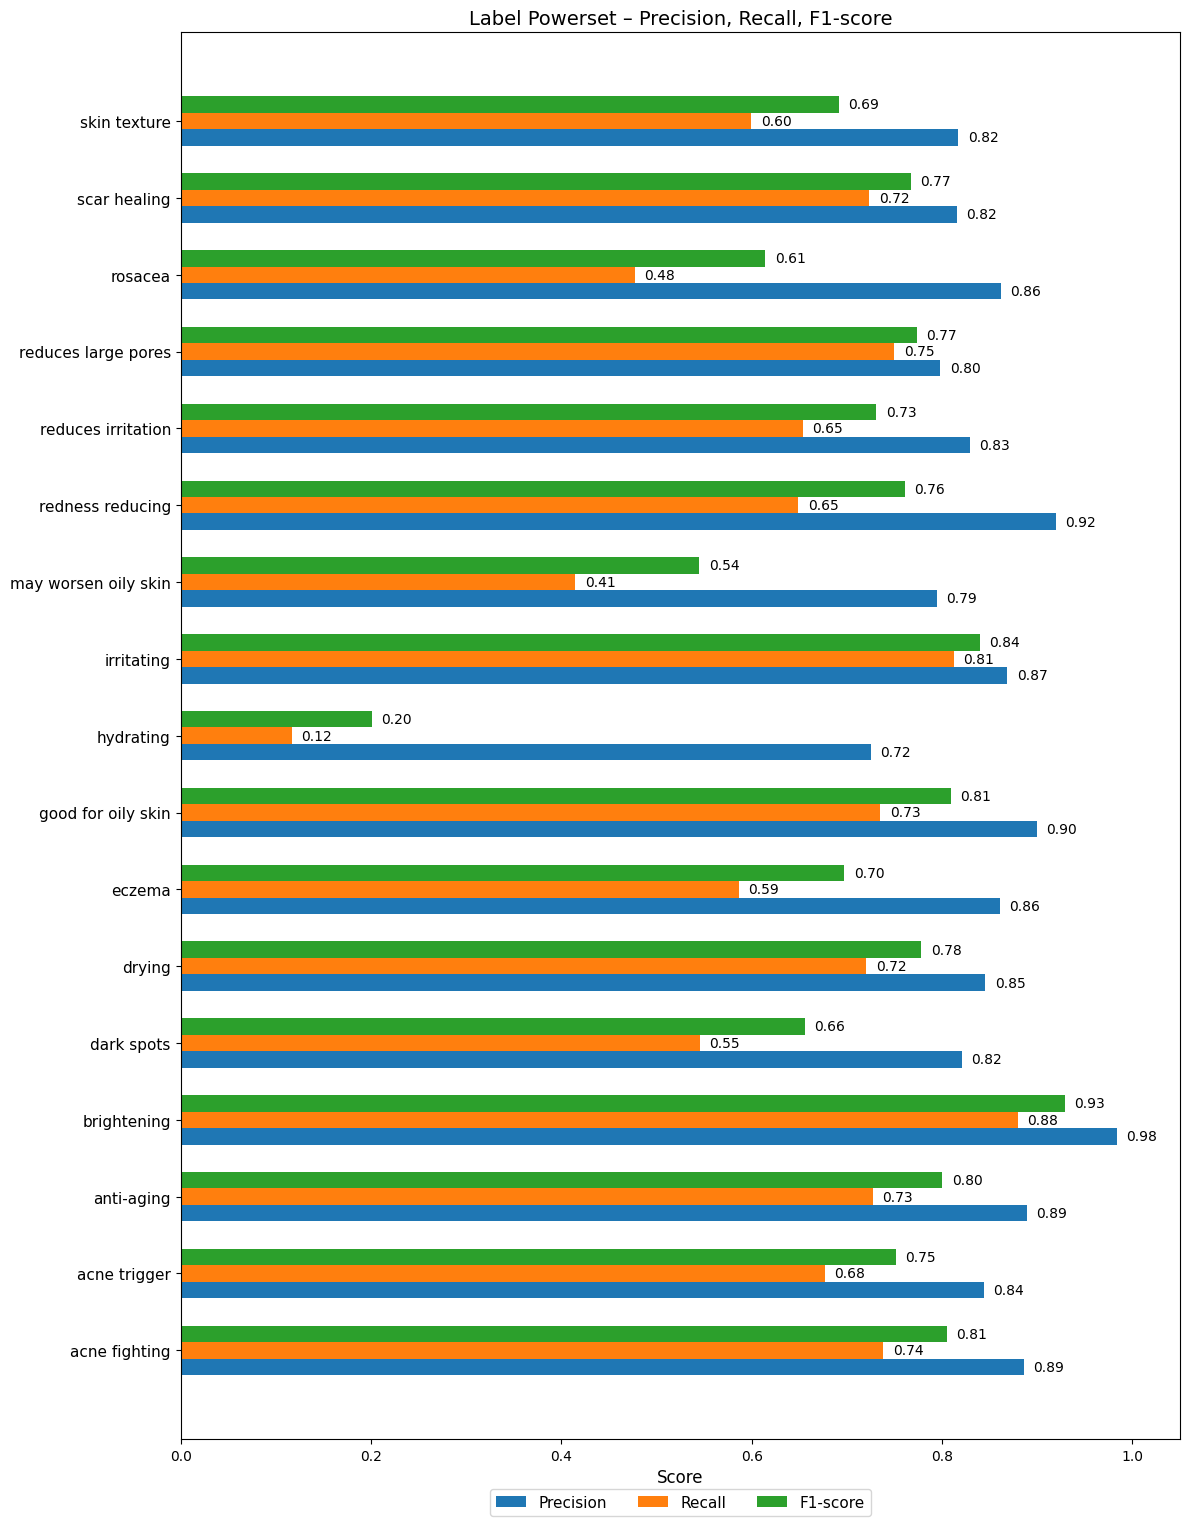

In [104]:
plot_multilabel_bar(
    df_br,
    mlb.classes_,
    "Binary Relevance – Precision, Recall, F1-score"
)

plot_multilabel_bar(
    df_cc,
    mlb.classes_,
    "Classifier Chain – Precision, Recall, F1-score"
)

plot_multilabel_bar(
    df_lp,
    mlb.classes_,
    "Label Powerset – Precision, Recall, F1-score"
)


In [109]:
from sklearn.metrics import confusion_matrix
import math

def plot_multilabel_confusion_matrix(
    y_true,
    y_pred,
    label_names,
    model_name,
    n_cols=4,
    figsize_scale=(4, 4)
):
    cmap_dict = {
        "Binary Relevance": "Greens",
        "Classifier Chain": "Blues",
        "Label Powerset": "Reds"
    }
    cmap = cmap_dict.get(model_name, "Blues")

    n_labels = len(label_names)
    n_rows = math.ceil(n_labels / n_cols)

    plt.figure(figsize=(n_cols * figsize_scale[0], n_rows * figsize_scale[1]))

    for i, label in enumerate(label_names):

        # pastikan array 1D
        y_true_i = y_true[:, i]
        y_pred_i = y_pred[:, i]

        # kalau sparse → ubah ke dense
        if not isinstance(y_pred_i, np.ndarray):
            y_pred_i = y_pred_i.toarray().ravel()

        cm = confusion_matrix(
            y_true_i,
            y_pred_i,
            labels=[0, 1]
        )

        plt.subplot(n_rows, n_cols, i + 1)
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap=cmap,
            cbar=False,
            square=True
        )

        plt.title(label, fontsize=10)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")

    plt.suptitle(
        f"Confusion Matrix per Label – {model_name}",
        fontsize=14
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


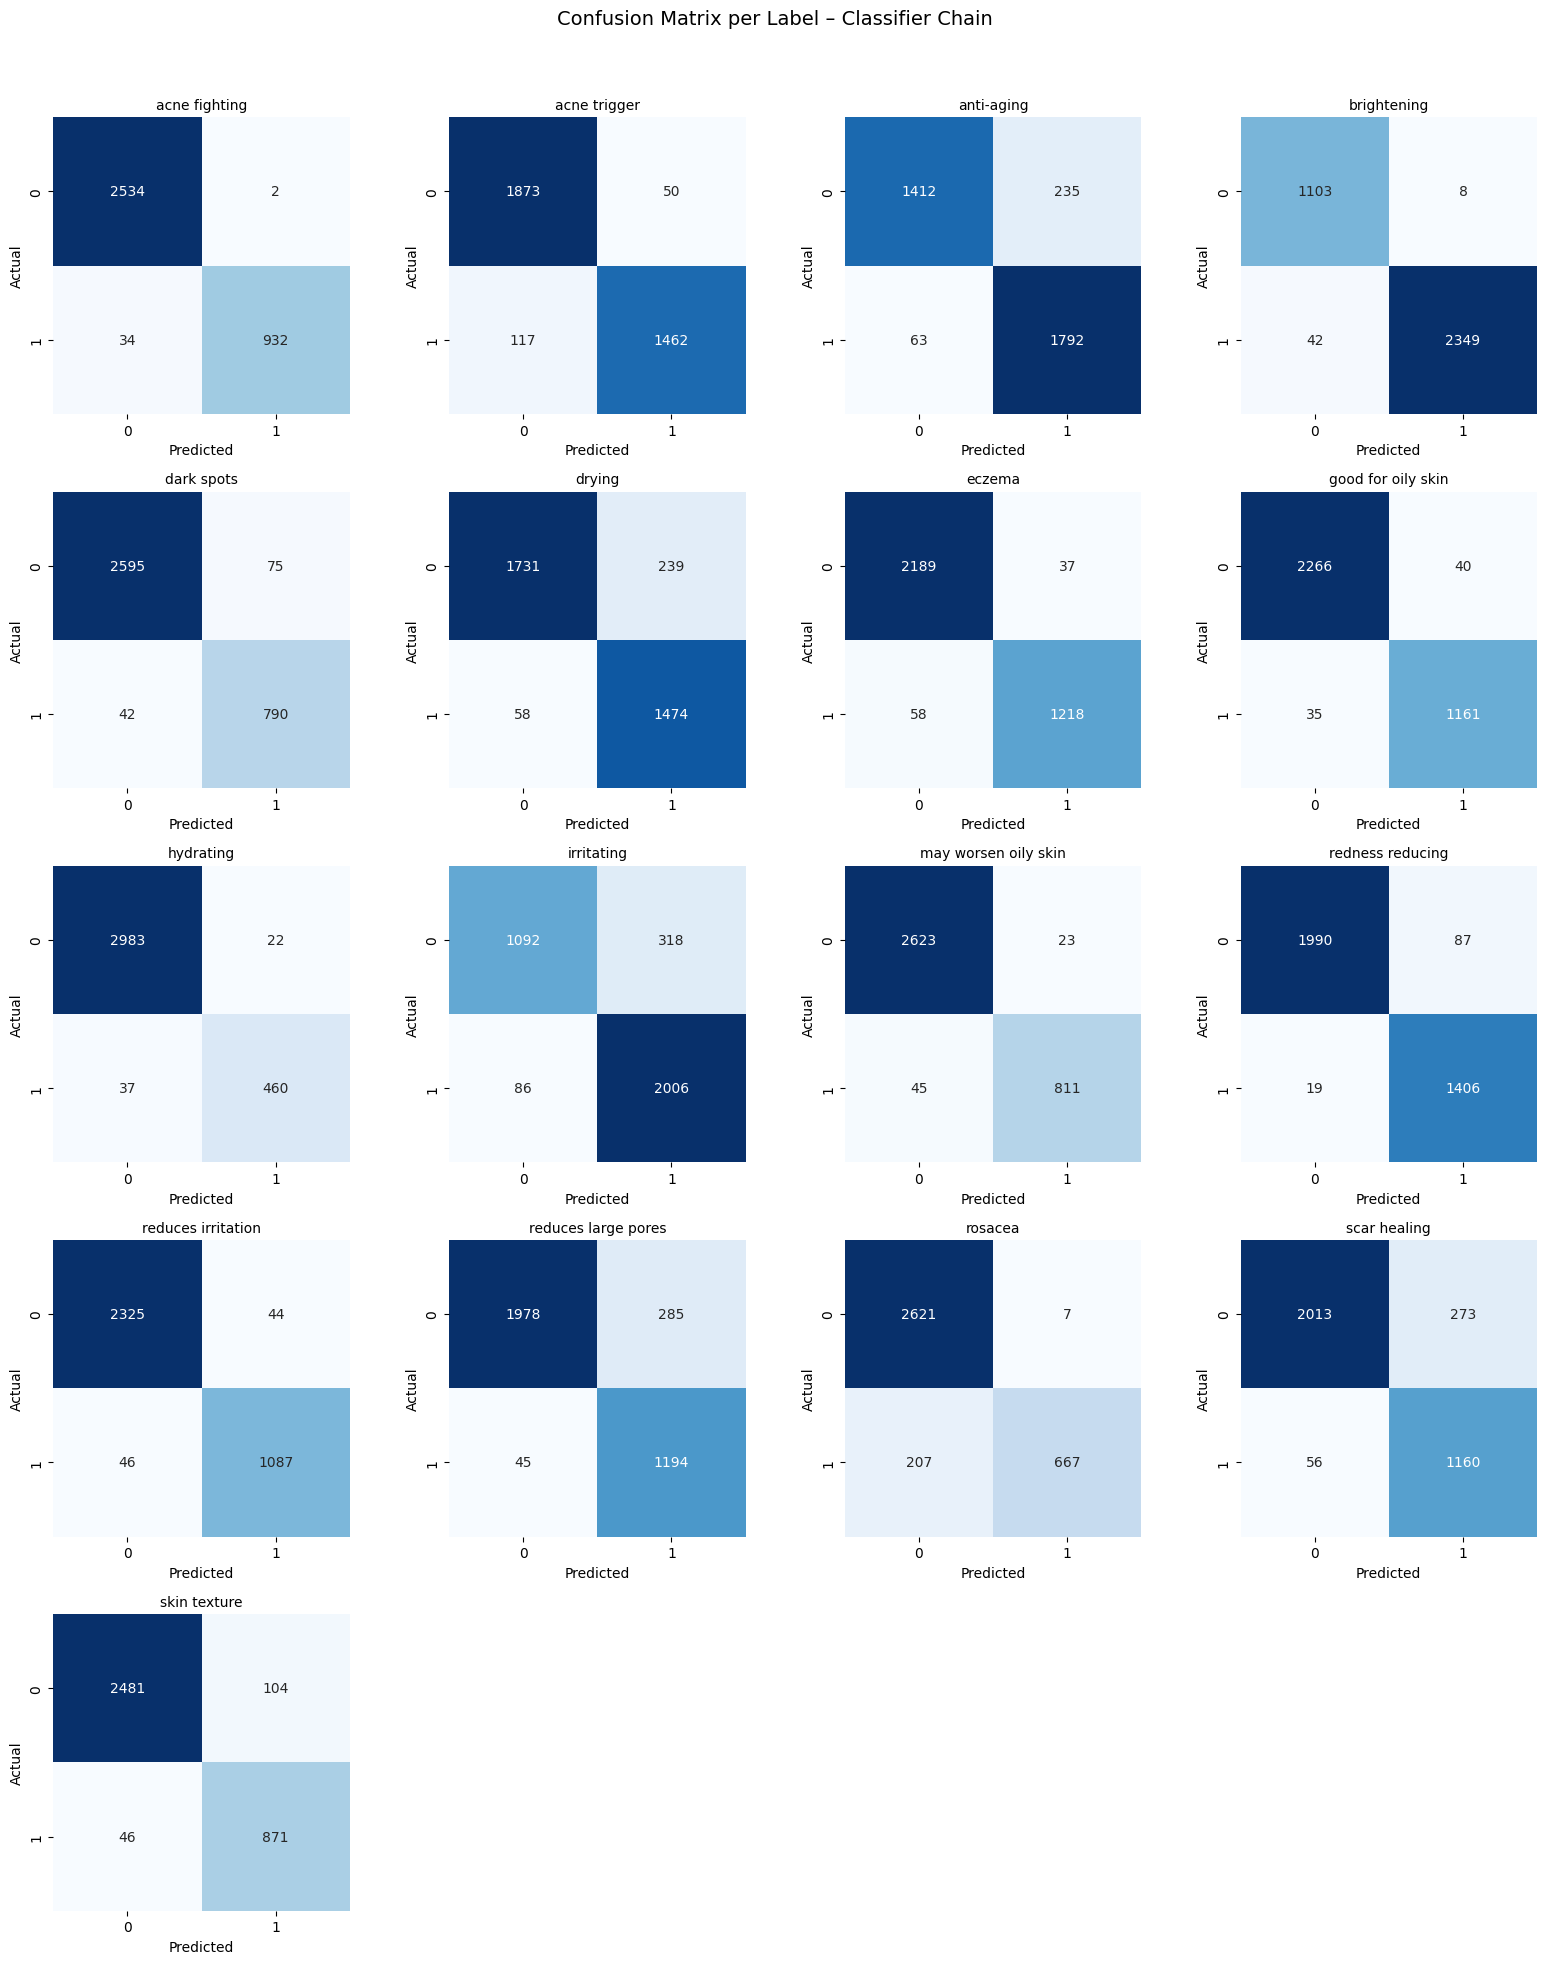

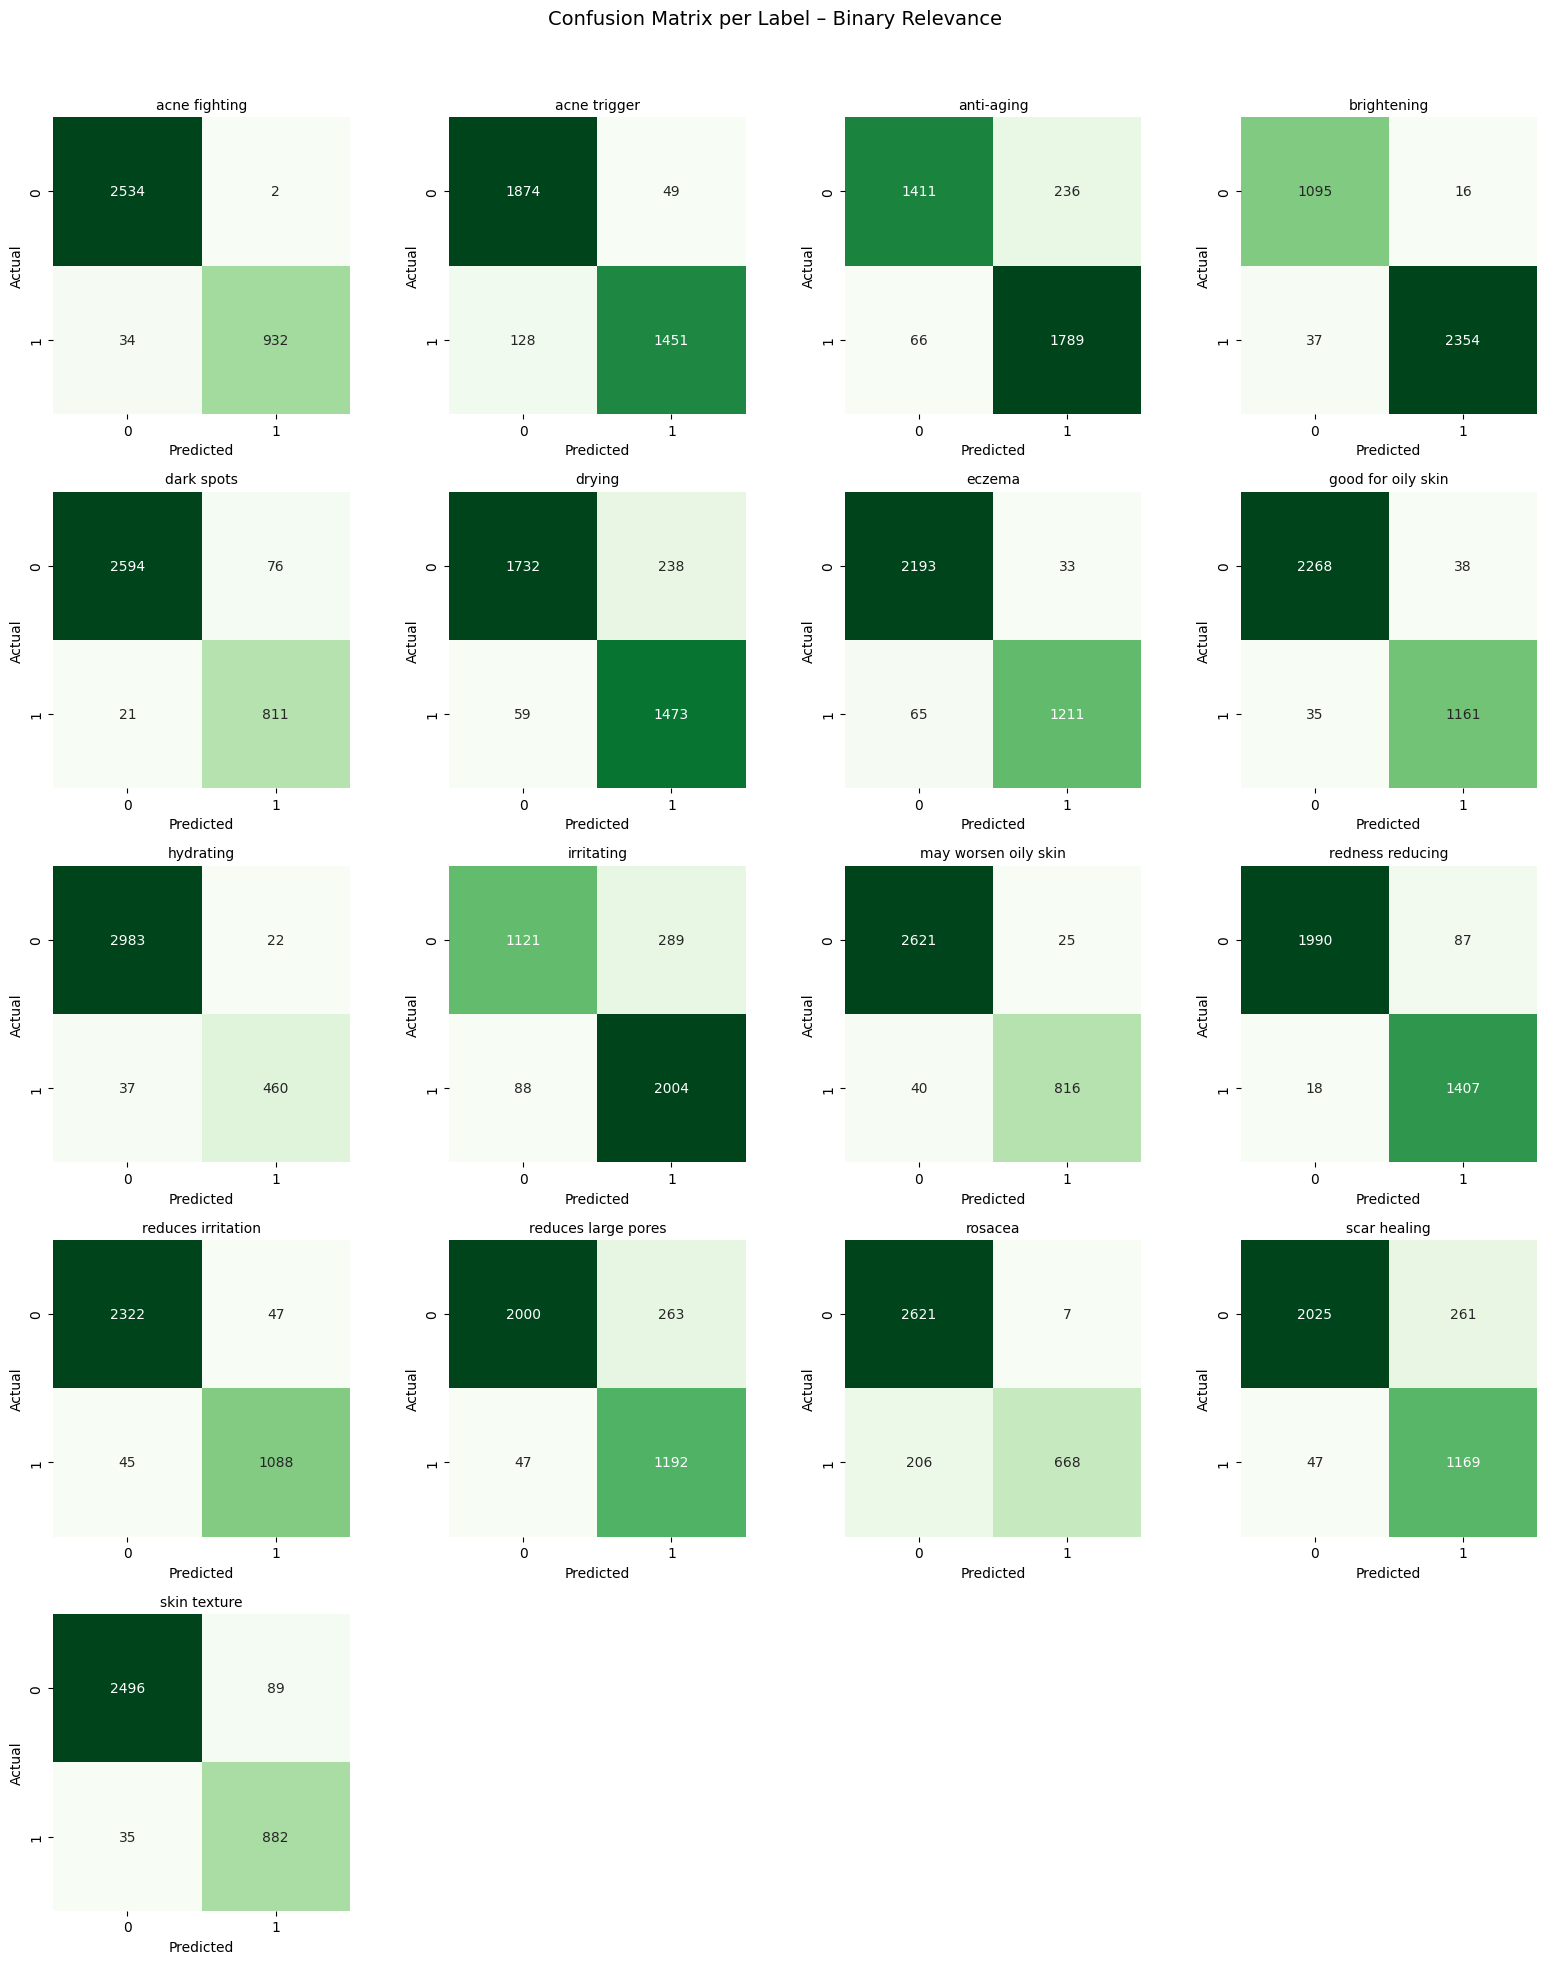

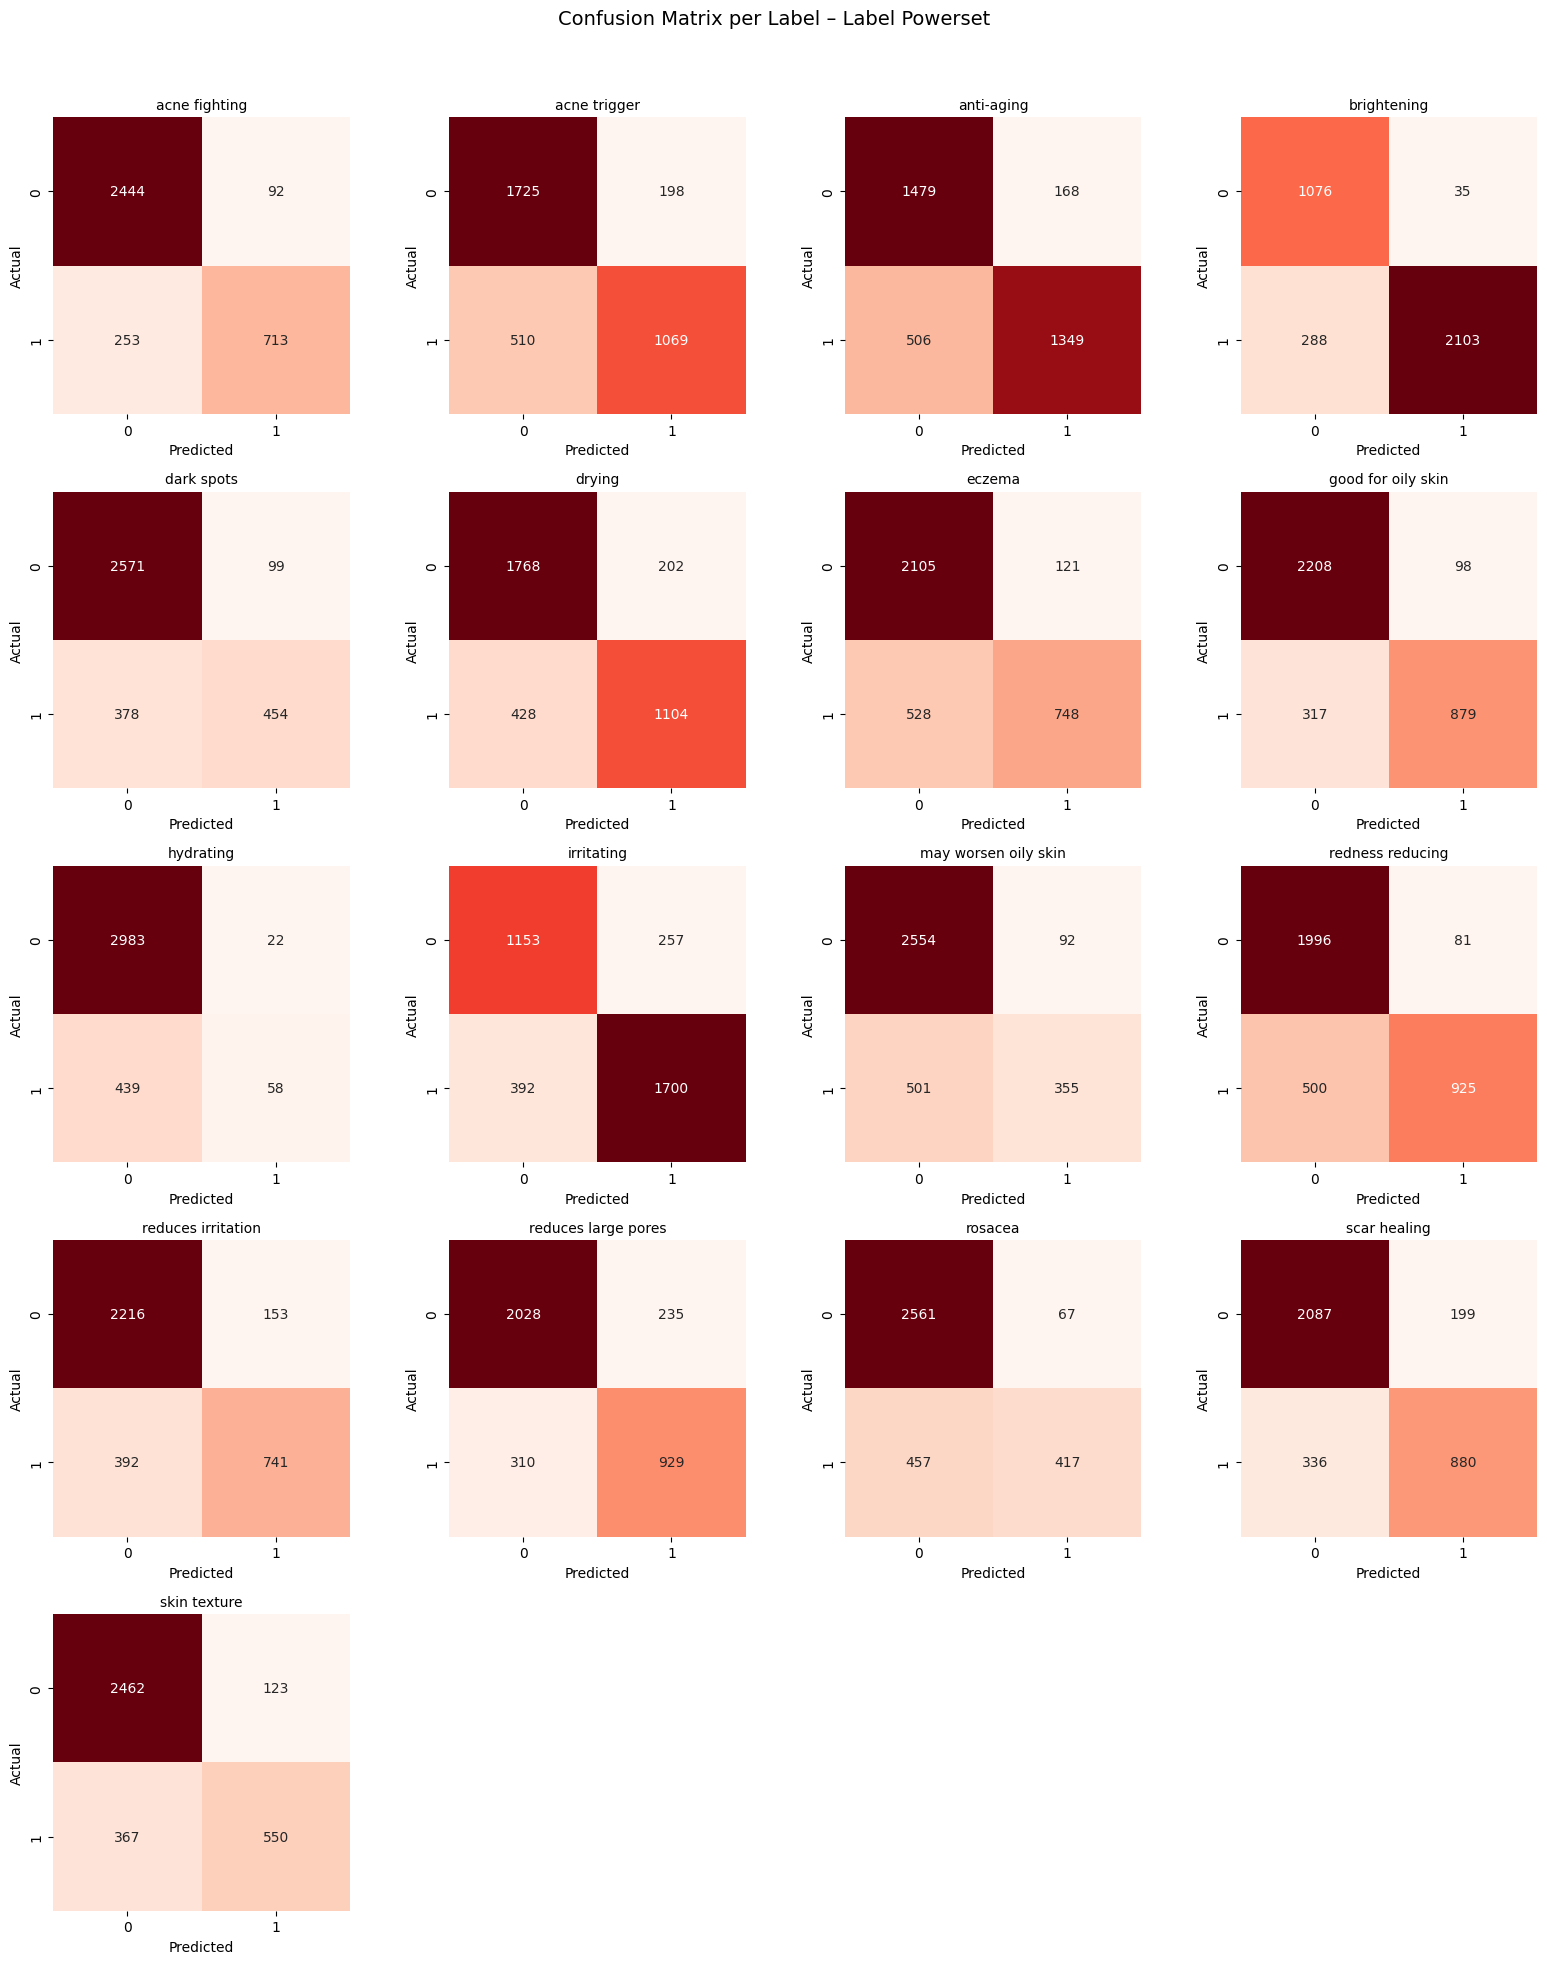

In [110]:
predictions = {
    "Classifier Chain": y_pred_cc,
    "Binary Relevance": y_pred_br,
    "Label Powerset": y_pred_lp
}

for name, y_pred in predictions.items():
    plot_multilabel_confusion_matrix(
        y_test,
        y_pred,
        mlb.classes_,
        model_name=name
    )

In [112]:
import pickle
import os

MODEL_DIR = "D:\SKRIPSI\save_model"
os.makedirs(MODEL_DIR, exist_ok=True)

# 1. Simpan TF-IDF
with open(os.path.join(MODEL_DIR, "tfidf.pkl"), "wb") as f:
    pickle.dump(tfidf_ing, f)

# 2. Simpan fitur terpilih (hasil MI + CS + ACO)
with open(os.path.join(MODEL_DIR, "selected_features.pkl"), "wb") as f:
    pickle.dump(X_ing_chi, f)

# 3. Simpan nama/urutan label
with open(os.path.join(MODEL_DIR, "label_names.pkl"), "wb") as f:
    pickle.dump(label_names, f)

# 4. Simpan MultiLabelBinarizer (WAJIB untuk multilabel)
with open(os.path.join(MODEL_DIR, "mlb.pkl"), "wb") as f:
    pickle.dump(mlb, f)

# 5. Simpan masing-masing model
models = {
    "binary_relevance": br_model,
    "classifier_chain": cc_model,
    "label_powerset": lp_model
}

for name, model in models.items():
    file_path = os.path.join(MODEL_DIR, f"{name}.pkl")
    with open(file_path, "wb") as f:
        pickle.dump(model, f)

    print(f"Model '{name}' berhasil disimpan di: {file_path}")


Model 'binary_relevance' berhasil disimpan di: D:\SKRIPSI\save_model\binary_relevance.pkl
Model 'classifier_chain' berhasil disimpan di: D:\SKRIPSI\save_model\classifier_chain.pkl
Model 'label_powerset' berhasil disimpan di: D:\SKRIPSI\save_model\label_powerset.pkl


In [116]:
import os
import pickle
import joblib


MODEL_DIR = "D:\SKRIPSI\deploy"
os.makedirs(MODEL_DIR, exist_ok=True)

# 1. Simpan TF-IDF
with open(os.path.join(MODEL_DIR, "selected_idx.pkl"), "wb") as f:
    pickle.dump(selected_idx, f)

In [118]:
import joblib

v = joblib.load("tfidf_ing.pkl")
print(type(v))
print(hasattr(v, "idf_"))

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
True


In [124]:
import joblib
import os

MODEL_DIR = "D:/SKRIPSI/deploy"  # ✅ pakai slash aman

os.makedirs(MODEL_DIR, exist_ok=True)

# ✅ 1. TF-IDF (SUDAH FIT)
joblib.dump(tfidf_ing, os.path.join(MODEL_DIR, "fix_tfidf_ing.pkl"))

# ✅ 2. INDEX FITUR (INI YANG BENAR)
joblib.dump(selected_idx, os.path.join(MODEL_DIR, "fix_selected_idx.pkl"))

# ✅ 3. MODEL
joblib.dump(cc_model, os.path.join(MODEL_DIR, "fix_classifier_chain.pkl"))

# ✅ 4. MLB
joblib.dump(mlb, os.path.join(MODEL_DIR, "fix_mlb.pkl"))

print("✅ Semua model berhasil disimpan!")

✅ Semua model berhasil disimpan!


In [127]:
import joblib
import os

MODEL_DIR = "D:/SKRIPSI/deploy"  # ✅ pakai slash aman

os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(selected_features, os.path.join(MODEL_DIR, "fix_selected_features.pkl"))


['D:/SKRIPSI/deploy\\fix_selected_features.pkl']

In [125]:
print("CEK SEBELUM SAVE:", hasattr(tfidf_ing, "idf_"))

CEK SEBELUM SAVE: True


In [129]:
import joblib
import os

MODEL_DIR = "D:/SKRIPSI/test_deploy"  # ✅ pakai slash aman

os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(feature_names_ing, os.path.join(MODEL_DIR, "fix_feature_names_ing.pkl"))

['D:/SKRIPSI/test_deploy\\fix_feature_names_ing.pkl']

In [ ]:
feature_names_ing